In [93]:
import os
import pandas as pd
from types import SimpleNamespace

# Define the arguments
args = SimpleNamespace(
    data_dir="/scratch/work/masooda1/datasets/mocop",
    output_dir="/scratch/work/masooda1/datasets/mocop",
    is_centered=True  # or False depending on your needs
)

def drop_bad_columns(df):
    cols = [c for c in df.columns if "Metadata" not in c]
    stdev = [df[c].std() for c in cols]

    cols_to_drop = []
    cols_to_drop.extend([cols[i] for i, s in enumerate(stdev) if s < 0.1 or s > 5])
    cols_to_drop.extend([c for c in cols if "Nuclei_Correlation_RWC" in c])
    cols_to_drop.extend([c for c in cols if "Nuclei_Correlation_Manders" in c])
    cols_to_drop.extend([c for c in cols if "Nuclei_Granularity_14" in c])
    cols_to_drop.extend([c for c in cols if "Nuclei_Granularity_15" in c])
    cols_to_drop.extend([c for c in cols if "Nuclei_Granularity_16" in c])
    df = df[[c for c in df.columns if c not in cols_to_drop]]
    return df

def clean_dataframe(df, metadata_keyword="Metadata"):
    """
    Clean DataFrame by dropping feature columns with NaN values while preserving metadata columns,
    then remove rows with NaN values.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Input DataFrame containing both feature and metadata columns
    metadata_keyword : str, default="Metadata"
        Keyword used to identify metadata columns
        
    Returns:
    --------
    pandas.DataFrame
        Cleaned DataFrame with:
        - Feature columns containing NaN values removed
        - Metadata columns preserved
        - Rows containing NaN values removed
    """
    # Get feature and metadata columns
    feature_cols = [c for c in df.columns if metadata_keyword not in c]
    metadata_cols = [c for c in df.columns if metadata_keyword in c]
    
    # Drop feature columns with NaN values
    feature_df = df[feature_cols].dropna(axis=1)
    
    # Combine back with metadata columns
    cleaned_df = pd.concat([df[metadata_cols], feature_df], axis=1)
    
    # Drop rows with NaN values
    cleaned_df = cleaned_df.dropna(axis=0)
    
    return cleaned_df

def main(args):
    data_dir = args.data_dir
    output_dir = args.output_dir
    is_centered = args.is_centered
    dfs = []
    
    # Add counter
    count = 0
    for f in os.listdir(data_dir):
        if count >= 20:  # Break after 5 files
            break
            
        if is_centered and "centered" not in f:
            continue
            
        print(f"Processing file {count + 1}: {f}")  # Added print for visibility
        df = pd.read_parquet(os.path.join(data_dir, f))
        dfs.append(df)
        count += 1

    df = pd.concat(dfs)
    df = drop_bad_columns(df)
    df = clean_dataframe(df)
    
    filename = f"{'centered.' if is_centered else ''}filtered.parquet"
    filepath = os.path.join(output_dir, filename)
    #df.to_parquet(filepath)
    print(f"File saved to {filepath}")
    return df#, df_updated

In [94]:
# Run the main function
df = main(args)
feature_cols = [c for c in df.columns if "Metadata" not in c]
len(feature_cols)

Processing file 1: source_3.CP_26_all_Phenix1.J12459b.J12459b.centered.parquet
Processing file 2: source_10.2021_08_03_U2OS_48_hr_run12.Dest210726-162329.Dest210726-162329.centered.parquet
Processing file 3: source_8.J4.A1166165.A1166165.centered.parquet
Processing file 4: source_2.20210816_Batch_9.1086292303.1086292303.centered.parquet
Processing file 5: source_10.2021_08_23_U2OS_48_hr_run18.Dest210823-174733.Dest210823-174733.centered.parquet
Processing file 6: source_3.CP_28_all_Phenix1.SP16P19b.SP16P19b.centered.parquet
Processing file 7: source_7.20210723_Run2.CP2-SC1-18.CP2-SC1-18.centered.parquet
Processing file 8: source_7.20210727_Run3.CP3-SC1-21.CP3-SC1-21.centered.parquet
Processing file 9: source_2.20210726_Batch_7.1086293539.1086293539.centered.parquet
Processing file 10: source_5.JUMPCPE-20210820-Run23_20210823_145853.AEOJUM502.AEOJUM502.centered.parquet
Processing file 11: source_3.CP_27_all_Phenix1.J12450a.J12450a.centered.parquet
Processing file 12: source_10.2021_08_0

3936

In [95]:
df

,Metadata_JCP2022,Metadata_InChIKey,Metadata_InChI,Metadata_Source,Metadata_Plate,Metadata_Well,Cells_AreaShape_BoundingBoxMaximum_X,Cells_AreaShape_BoundingBoxMaximum_Y,Cells_AreaShape_BoundingBoxMinimum_X,Cells_AreaShape_BoundingBoxMinimum_Y,...,Nuclei_Texture_Variance_RNA_10_02_256,Nuclei_Texture_Variance_RNA_10_03_256,Nuclei_Texture_Variance_RNA_3_00_256,Nuclei_Texture_Variance_RNA_3_01_256,Nuclei_Texture_Variance_RNA_3_02_256,Nuclei_Texture_Variance_RNA_3_03_256,Nuclei_Texture_Variance_RNA_5_00_256,Nuclei_Texture_Variance_RNA_5_01_256,Nuclei_Texture_Variance_RNA_5_02_256,Nuclei_Texture_Variance_RNA_5_03_256
0,JCP2022_000107,AAMVLFNKCTYKQK-UHFFFAOYSA-N,InChI=1S/C16H14ClF3N4O2S/c1-9-3-4-10(2)13(5-9)...,source_3,J12459b,A06,0.425889,1.224017,0.461136,1.445225,...,-0.573081,-0.552658,-0.600901,-0.604635,-0.605231,-0.630925,-0.604198,-0.588822,-0.614205,-0.618853
1,JCP2022_000650,ADHRTDCPVLEXRX-UHFFFAOYSA-N,InChI=1S/C20H23FN2O4S/c1-4-10-23-17-12-15(8-9-...,source_3,J12459b,B12,1.226293,0.480072,1.446827,0.782493,...,-0.501064,-0.508441,-0.548440,-0.557160,-0.557706,-0.582208,-0.563281,-0.558679,-0.561192,-0.568043
2,JCP2022_000840,AEIMQQRZBRSHMV-UHFFFAOYSA-N,InChI=1S/C22H25N5O3S/c28-21(17-19-7-3-6-18-5-1...,source_3,J12459b,F12,-0.762052,0.175589,-0.716060,0.348786,...,-0.266047,-0.197934,-0.274005,-0.268005,-0.262871,-0.300091,-0.282915,-0.282114,-0.276959,-0.289825
3,JCP2022_000849,AEJQBQKIAKJDTG-UHFFFAOYSA-N,InChI=1S/C19H13ClFNOS/c20-12-7-5-11(6-8-12)15-...,source_3,J12459b,P19,-1.177801,0.441191,-1.174612,0.506170,...,0.666411,0.684144,0.650839,0.676506,0.648983,0.653004,0.695250,0.675727,0.675964,0.703252
4,JCP2022_001460,AHPBNONCZISZFX-UHFFFAOYSA-N,InChI=1S/C22H21N3O2/c26-21(23-16-9-8-12-2-1-3-...,source_3,J12459b,D10,-0.795767,-1.173774,-0.774533,-1.105728,...,0.271136,0.251261,0.232200,0.258772,0.246240,0.220801,0.241864,0.264709,0.257808,0.236439
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
377,JCP2022_114868,ZPQMSAHRWBOMHB-UHFFFAOYSA-N,InChI=1S/C17H19NO3/c1-11-16(14-5-3-4-6-15(14)2...,source_11,EC000164,A08,-0.357785,-1.339025,-0.499220,-1.531865,...,-0.570317,-0.532741,-0.626319,-0.637579,-0.620738,-0.646267,-0.643765,-0.644615,-0.632321,-0.624765
378,JCP2022_114979,ZQGGRBIDRBYUJS-UHFFFAOYSA-N,InChI=1S/C10H12N2O/c11-8-3-1-4-9(7-8)12-6-2-5-...,source_11,EC000164,M11,1.053980,0.220978,1.037405,0.219003,...,0.143181,0.183309,0.166625,0.163135,0.188720,0.151923,0.146903,0.151728,0.167031,0.157905
379,JCP2022_115929,ZVKLHIPGOQNOLB-UHFFFAOYSA-N,InChI=1S/C14H23NO3/c1-10(2)9-15-13(17)11-8-12(...,source_11,EC000164,J18,-0.149413,0.498250,-0.201559,0.489572,...,0.425917,0.441141,0.434491,0.441027,0.439041,0.437747,0.440483,0.444652,0.450366,0.466423
380,JCP2022_116606,ZZDDBBZBNGACOV-UHFFFAOYSA-N,InChI=1S/C16H17Cl2NO3/c17-11-5-4-6-12(18)14(11...,source_11,EC000164,I12,0.997445,-0.606918,0.976623,-0.602549,...,0.419084,0.332285,0.420441,0.410496,0.423765,0.427470,0.426340,0.432803,0.428733,0.437176


In [9]:
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem, inchi

In [112]:
from rdkit import Chem
import pandas as pd
from sklearn.model_selection import train_test_split

def inchi2smiles(inchi_str: str):
    # Attempt conversion with sanitization disabled
    mol = Chem.inchi.MolFromInchi(inchi_str)
    if mol is None:
        raise ValueError(f"Invalid InChI string: {inchi_str}")
    return Chem.MolToSmiles(mol)

def convert_inchi_to_smiles(df):
    
    # Convert InChI to SMILES and create new column
    print("Converting InChI to SMILES...")
    df['Metadata_SMILES'] = df['Metadata_InChI'].apply(inchi2smiles)
    
    # Count successful conversions
    successful = df['Metadata_SMILES'].notna().sum()
    total = len(df)
    print(f"Successfully converted {successful}/{total} InChIs to SMILES ({successful/total*100:.2f}%)")
    
    # Reorder columns to put Metadata_SMILES first
    cols = df.columns.tolist()
    cols.remove('Metadata_SMILES')
    new_cols = ['Metadata_SMILES'] + cols
    df = df[new_cols]
    return df

def create_splits(df, seed=42):
    """
    Create train (90%), validation (5%), and test (5%) splits
    """
    # First split: 90% train, 10% temp
    train_df, temp_df = train_test_split(df, test_size=0.1, random_state=seed)
    
    # Second split: Split temp into two equal parts (5% each for val and test)
    val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=seed)
    
    print(f"Split sizes:")
    print(f"Train: {len(train_df)} ({len(train_df)/len(df)*100:.1f}%)")
    print(f"Val:   {len(val_df)} ({len(val_df)/len(df)*100:.1f}%)")
    print(f"Test:  {len(test_df)} ({len(test_df)/len(df)*100:.1f}%)")
    
    return train_df, val_df, test_df

 # Read the parquet file
print("Reading parquet file...")
df = pd.read_parquet('/scratch/work/masooda1/datasets/mocop/source_1.Batch1_20221004.UL001641.UL001641.parquet')
print(f"Initial shape: {df.shape}")
df = convert_inchi_to_smiles(df)

for split_num in range(3):
    print(f"\nCreating split {split_num}")
    train_df, val_df, test_df = create_splits(df, seed=split_num)

Reading parquet file...
Initial shape: (1472, 4768)
Converting InChI to SMILES...
Successfully converted 1472/1472 InChIs to SMILES (100.00%)

Creating split 0
Split sizes:
Train: 1324 (89.9%)
Val:   74 (5.0%)
Test:  74 (5.0%)

Creating split 1
Split sizes:
Train: 1324 (89.9%)
Val:   74 (5.0%)
Test:  74 (5.0%)

Creating split 2
Split sizes:
Train: 1324 (89.9%)
Val:   74 (5.0%)
Test:  74 (5.0%)


In [98]:
from rdkit import Chem
import pandas as pd
from sklearn.model_selection import train_test_split
import os

def inchi2smiles(inchi_str: str):
    # Attempt conversion with sanitization disabled
    mol = Chem.inchi.MolFromInchi(inchi_str)
    if mol is None:
        raise ValueError(f"Invalid InChI string: {inchi_str}")
    return Chem.MolToSmiles(mol)

def convert_inchi_to_smiles(df):
    # Convert InChI to SMILES and create new column
    print("Converting InChI to SMILES...")
    df['Metadata_SMILES'] = df['Metadata_InChI'].apply(inchi2smiles)
    
    # Count successful conversions
    successful = df['Metadata_SMILES'].notna().sum()
    total = len(df)
    print(f"Successfully converted {successful}/{total} InChIs to SMILES ({successful/total*100:.2f}%)")
    
    # Reorder columns to put Metadata_SMILES first
    cols = df.columns.tolist()
    cols.remove('Metadata_SMILES')
    new_cols = ['Metadata_SMILES'] + cols
    df = df[new_cols]
    return df

def create_splits(df, seed=42):
    """
    Create train (90%), validation (5%), and test (5%) splits
    """
    # First split: 90% train, 10% temp
    train_df, temp_df = train_test_split(df, test_size=0.1, random_state=seed)
    
    # Second split: Split temp into two equal parts (5% each for val and test)
    val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=seed)
    
    print(f"Split sizes:")
    print(f"Train: {len(train_df)} ({len(train_df)/len(df)*100:.1f}%)")
    print(f"Val:   {len(val_df)} ({len(val_df)/len(df)*100:.1f}%)")
    print(f"Test:  {len(test_df)} ({len(test_df)/len(df)*100:.1f}%)")
    
    return train_df, val_df, test_df

def save_splits(train_df, val_df, test_df, output_dir, split_num):
    """
    Save the splits to CSV files
    """
    os.makedirs(output_dir, exist_ok=True)
    
    # Save splits
    train_path = os.path.join(output_dir, f'jump-compound-split-{split_num}-train.csv')
    val_path = os.path.join(output_dir, f'jump-compound-split-{split_num}-val.csv')
    test_path = os.path.join(output_dir, f'jump-compound-split-{split_num}-test.csv')
    
    train_df.to_csv(train_path, index=False)
    val_df.to_csv(val_path, index=False)
    test_df.to_csv(test_path, index=False)
    
    print(f"\nSaved splits to:")
    print(f"Train: {train_path}")
    print(f"Val:   {val_path}")
    print(f"Test:  {test_path}")

def main():
    # Read the parquet file
    print("Reading parquet file...")
    df = pd.read_parquet('/scratch/work/masooda1/datasets/mocop/source_1.Batch1_20221004.UL001641.UL001641.parquet')
    print(f"Initial shape: {df.shape}")
    
    # Convert InChI to SMILES
    df = convert_inchi_to_smiles(df)
    
    # Create splits for 3 different random seeds
    output_dir = '/scratch/work/masooda1/mocop/data/jump'
    
    for split_num in range(3):
        print(f"\nCreating split {split_num}")
        train_df, val_df, test_df = create_splits(df, seed=split_num)
        save_splits(train_df, val_df, test_df, output_dir, split_num)

if __name__ == "__main__":
    main()

Reading parquet file...
Initial shape: (1472, 4768)
Converting InChI to SMILES...
Successfully converted 1472/1472 InChIs to SMILES (100.00%)


In [99]:
df

,Metadata_SMILES,Metadata_JCP2022,Metadata_InChIKey,Metadata_InChI,Metadata_Source,Metadata_Plate,Metadata_Well,Cells_AreaShape_Area,Cells_AreaShape_BoundingBoxArea,Cells_AreaShape_BoundingBoxMaximum_X,...,Nuclei_Texture_Variance_RNA_10_02_256,Nuclei_Texture_Variance_RNA_10_03_256,Nuclei_Texture_Variance_RNA_3_00_256,Nuclei_Texture_Variance_RNA_3_01_256,Nuclei_Texture_Variance_RNA_3_02_256,Nuclei_Texture_Variance_RNA_3_03_256,Nuclei_Texture_Variance_RNA_5_00_256,Nuclei_Texture_Variance_RNA_5_01_256,Nuclei_Texture_Variance_RNA_5_02_256,Nuclei_Texture_Variance_RNA_5_03_256
0,Cc1nc(=N)[nH]cc1C(S)=Nc1ccccc1,JCP2022_000082,AAJUAUAIVHRTHW-UHFFFAOYSA-N,InChI=1S/C12H12N4S/c1-8-10(7-14-12(13)15-8)11(...,source_1,UL001641,AA40,3924.600098,7307.799805,597.270020,...,96.549004,102.059998,95.753998,93.674004,94.549004,93.532997,94.221001,93.199997,92.612999,93.917999
1,O=C(Cn1nnc(-c2ccccc2Br)n1)N(Cc1ccccc1)C1CCS(=O...,JCP2022_000084,AAJVQBOCLJBIKS-UHFFFAOYSA-N,InChI=1S/C20H20BrN5O3S/c21-18-9-5-4-8-17(18)20...,source_1,UL001641,R19,3796.300049,7069.700195,585.440002,...,73.292999,78.320000,71.555000,70.716003,71.504997,70.148003,70.258003,70.639999,70.278000,70.781998
2,CCOC(O)=Nc1ccc(OC)cc1OC,JCP2022_000137,AAQUZLDNXFPNNU-UHFFFAOYSA-N,InChI=1S/C11H15NO4/c1-4-16-11(13)12-9-6-5-8(14...,source_1,UL001641,Z22,4258.500000,7951.500000,566.950012,...,80.325996,81.766998,78.357002,77.092003,78.135002,76.955002,76.901001,77.491997,76.846001,76.852997
3,Cc1ccc(N=C(O)c2cccc(N=C(O)c3cc(F)c(F)c(F)c3F)c...,JCP2022_000368,ABXQDZFZWZARMF-UHFFFAOYSA-N,InChI=1S/C28H18F4N2O3/c1-15-10-11-22(19(12-15)...,source_1,UL001641,I23,4725.700195,8819.700195,597.030029,...,94.744003,99.080002,91.973999,90.690002,91.879997,90.602997,90.591003,91.224998,90.523003,91.390999
4,O=[N+]([O-])c1ccc(SCCOc2nonc2-c2ccccc2)cc1N1CC...,JCP2022_000428,ACFSNTGFRBWARG-UHFFFAOYSA-N,InChI=1S/C21H22N4O4S/c26-25(27)18-10-9-17(15-1...,source_1,UL001641,Z32,4228.100098,7967.299805,576.150024,...,88.119003,92.051003,86.152000,84.764999,85.763000,84.474998,84.551003,85.007004,84.291000,84.764000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1467,O=[N+]([O-])c1ccc2c(c1)[nH]c(=[N+]([O-])O)n2-c...,JCP2022_116460,ZYIYODUAWOZPSN-UHFFFAOYSA-N,InChI=1S/C11H8N4O5/c16-14(17)7-3-4-9-8(6-7)12-...,source_1,UL001641,L24,4300.600098,8125.600098,600.599976,...,84.060997,88.935997,82.107002,80.546997,81.695000,80.529999,80.632004,81.174004,80.178001,80.686996
1468,Cc1ccc2nsnc2c1S(=O)(=O)N1CCN=C1Cc1ccccc1,JCP2022_116497,ZYNUKOYPVSJYMR-UHFFFAOYSA-N,InChI=1S/C17H16N4O2S2/c1-12-7-8-14-16(20-24-19...,source_1,UL001641,L34,4340.799805,8089.700195,615.000000,...,112.489998,118.449997,109.849998,106.989998,108.059998,106.690002,107.879997,107.809998,106.330002,107.040001
1469,Cc1nc(-c2ccc([N+](=O)[O-])cc2)nn1CN1C(=O)c2ccc...,JCP2022_116640,ZZHVWZWFBCUXGJ-UHFFFAOYSA-N,InChI=1S/C18H13N5O4/c1-11-19-16(12-6-8-13(9-7-...,source_1,UL001641,U07,3625.100098,6680.299805,537.630005,...,69.051003,71.474998,67.981003,67.305000,68.505997,67.433998,67.054001,67.878998,67.262001,67.069000
1470,CC(C)S(=O)(=O)c1csc(C(=N)O)c1Cl,JCP2022_116678,ZZONNJJZOMQJBJ-UHFFFAOYSA-N,"InChI=1S/C8H10ClNO3S2/c1-4(2)15(12,13)5-3-14-7...",source_1,UL001641,C13,3587.699951,6588.600098,568.840027,...,81.763000,84.644997,80.302002,79.112000,80.418999,79.521004,79.170998,79.772003,78.960999,79.514999


In [100]:
train_SMILES = pd.read_csv("/scratch/work/masooda1/mocop/data/jump/jump-compound-split-0-train.csv")
val_SMILES = pd.read_csv("/scratch/work/masooda1/mocop/data/jump/jump-compound-split-0-val.csv")
test_SMILES = pd.read_csv("/scratch/work/masooda1/mocop/data/jump/jump-compound-split-0-test.csv")

In [108]:
df.Metadata_SMILES.isin(test_SMILES.SMILES).sum()

2

In [6]:
import pandas as pd
pd.read_csv("/scratch/work/masooda1/mocop/data/jump_data/jump-compound-split-0-train.csv")

,SMILES
0,Cn1cc(C(=O)N2CCCCC2c2n[nH]c(-c3ccccc3)n2)cn1
1,FC(F)(F)c1[nH]c2ncccc2c1CN1CCC(N2CCNCC2)CC1
2,CN1CCCN(C(=O)c2cnccn2)c2nc3ccccc3nc21
3,OC(COCc1cc(-c2cccs2)on1)=NCc1ccc(F)cc1
4,CC(C)(Cc1ccc2ccccc2c1)NCC(O)COc1cccc(Cl)c1C#N
...,...
104150,Cc1ccc(-c2nc(C3CC(=O)N(c4ccc(F)cc4)C3)no2)c(C)c1
104151,c1ccc(CCn2nnnc2CN2CCCc3ccccc32)cc1
104152,Cc1ncc(-c2cc(O)nc(=NCc3ccccn3)[nH]2)c(C)n1
104153,Cc1ccc2occ(C(=O)c3ccc(Cl)cc3)c(=O)c2c1


# Normalize Features

In [14]:
import pandas as pd

In [15]:
morph_data = pd.read_parquet("/scratch/work/masooda1/Multi_Modal_Contrastive/data/dummy_data/cell_fetures_with_smiles_2000.parquet")
morph_data.iloc[:,7:].describe()

,Cells_AreaShape_Area,Cells_AreaShape_BoundingBoxArea,Cells_AreaShape_BoundingBoxMaximum_X,Cells_AreaShape_BoundingBoxMaximum_Y,Cells_AreaShape_BoundingBoxMinimum_X,Cells_AreaShape_BoundingBoxMinimum_Y,Cells_AreaShape_Center_X,Cells_AreaShape_Center_Y,Cells_AreaShape_Compactness,Cells_AreaShape_Eccentricity,...,Nuclei_Texture_Variance_RNA_10_02_256,Nuclei_Texture_Variance_RNA_10_03_256,Nuclei_Texture_Variance_RNA_3_00_256,Nuclei_Texture_Variance_RNA_3_01_256,Nuclei_Texture_Variance_RNA_3_02_256,Nuclei_Texture_Variance_RNA_3_03_256,Nuclei_Texture_Variance_RNA_5_00_256,Nuclei_Texture_Variance_RNA_5_01_256,Nuclei_Texture_Variance_RNA_5_02_256,Nuclei_Texture_Variance_RNA_5_03_256
count,17764.000000,17764.000000,17764.000000,17764.000000,17764.000000,17764.000000,17764.000000,17764.000000,17764.000000,17764.000000,...,17764.000000,17764.000000,17764.000000,17764.000000,17764.000000,17764.000000,17764.000000,17764.000000,17764.000000,17764.000000
mean,18.301153,14.682942,0.393651,0.334148,-0.605984,-0.621329,-0.105036,-0.143004,4.492054,0.292803,...,2.234562,2.399328,2.443574,2.392642,2.442399,2.393321,2.358448,2.279960,2.357556,2.282037
std,155.093719,63.249092,1.311120,1.664992,1.348444,1.547212,1.001495,1.386634,8.393274,2.501592,...,4.721577,4.945910,5.009315,4.941032,5.016243,4.944046,4.891017,4.801272,4.902294,4.805720
min,-35.211884,-31.853573,-12.369824,-22.356792,-32.790554,-20.760372,-11.197203,-20.757244,-25.923223,-126.321136,...,-6.857013,-7.043898,-6.343674,-6.464441,-6.428077,-6.403496,-6.397037,-6.372331,-6.466953,-6.398016
25%,-0.110927,-0.116085,-0.308646,-0.336117,-1.223663,-1.181887,-0.618844,-0.617916,-0.219539,-0.568930,...,-0.274189,-0.251077,-0.253125,-0.259002,-0.253527,-0.260735,-0.264335,-0.274674,-0.266356,-0.275376
50%,1.045084,1.030586,0.254134,0.342058,-0.375007,-0.404810,-0.060940,-0.015718,0.907615,0.201819,...,0.463727,0.525405,0.496025,0.483803,0.493322,0.480704,0.475148,0.464234,0.475008,0.466368
75%,27.967787,26.108912,1.003063,1.101370,0.198995,0.267611,0.471571,0.568715,7.984426,1.106928,...,3.224925,3.486197,3.515839,3.441186,3.499972,3.439928,3.390642,3.266725,3.385228,3.257151
max,11449.877930,3075.552979,26.928368,26.219355,6.108621,15.530707,6.053208,15.332897,553.655945,31.282068,...,132.829239,145.259521,122.712303,125.042397,121.460564,123.938324,124.386963,130.285385,124.375862,128.239151


In [77]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Load your data
morph_data = pd.read_parquet("/scratch/work/masooda1/mocop/data/dummy_data/cell_fetures_with_smiles_2000.parquet")
controls = pd.read_csv("/scratch/work/masooda1/mocop/data/jump_data/jump_controls.csv")

# filter postive, negative controls
morph_data = morph_data[~morph_data.Metadata_InChIKey.isin(controls.Metadata_InChIKey_pos_neg_control)].reset_index(drop = True)

# Separate SMILES (if any) and features
# Assuming that morphological features start from column index 7
meta_data = morph_data.iloc[:, :7]   # e.g., SMILES or other non-feature columns
features = morph_data.iloc[:, 7:]    # numerical features to normalize

# Initialize the scaler
scaler = StandardScaler()

# Fit and transform the features
normalized_features = scaler.fit_transform(features)

# Convert back to DataFrame if needed
normalized_df = pd.DataFrame(normalized_features, columns=features.columns)

# Optionally, recombine with meta data
normalized_morph_data = pd.concat([meta_data.reset_index(drop=True), normalized_df], axis=1)
normalized_morph_data.to_parquet("/scratch/work/masooda1/mocop/data/dummy_data/normalized_cell_fetures_with_smiles_2000.parquet")

In [15]:
normalized_morph_data.iloc[:,7:].describe()

,Cells_AreaShape_BoundingBoxMaximum_X,Cells_AreaShape_BoundingBoxMaximum_Y,Cells_AreaShape_BoundingBoxMinimum_X,Cells_AreaShape_BoundingBoxMinimum_Y,Cells_AreaShape_Center_X,Cells_AreaShape_Center_Y,Cells_AreaShape_Eccentricity,Cells_AreaShape_Extent,Cells_AreaShape_Orientation,Cells_AreaShape_Solidity,...,Nuclei_Texture_SumEntropy_RNA_10_02_256,Nuclei_Texture_SumEntropy_RNA_10_03_256,Nuclei_Texture_SumEntropy_RNA_3_00_256,Nuclei_Texture_SumEntropy_RNA_3_01_256,Nuclei_Texture_SumEntropy_RNA_3_02_256,Nuclei_Texture_SumEntropy_RNA_3_03_256,Nuclei_Texture_SumEntropy_RNA_5_00_256,Nuclei_Texture_SumEntropy_RNA_5_01_256,Nuclei_Texture_SumEntropy_RNA_5_02_256,Nuclei_Texture_SumEntropy_RNA_5_03_256
count,1.776400e+04,1.776400e+04,1.776400e+04,1.776400e+04,1.776400e+04,1.776400e+04,1.776400e+04,1.776400e+04,1.776400e+04,1.776400e+04,...,1.776400e+04,1.776400e+04,1.776400e+04,1.776400e+04,1.776400e+04,1.776400e+04,1.776400e+04,1.776400e+04,1.776400e+04,1.776400e+04
mean,-1.499964e-17,-1.979952e-17,-1.439965e-17,-1.719958e-17,-2.199947e-17,7.599815e-18,1.599961e-18,-3.199922e-18,9.599767e-18,2.239946e-17,...,1.679959e-17,4.079901e-17,-2.639936e-17,7.999806e-19,-2.999927e-17,-5.359870e-17,-3.119924e-17,1.199971e-17,-2.119948e-17,1.559962e-17
std,1.000028e+00,1.000028e+00,1.000028e+00,1.000028e+00,1.000028e+00,1.000028e+00,1.000028e+00,1.000028e+00,1.000028e+00,1.000028e+00,...,1.000028e+00,1.000028e+00,1.000028e+00,1.000028e+00,1.000028e+00,1.000028e+00,1.000028e+00,1.000028e+00,1.000028e+00,1.000028e+00
min,-9.735049e+00,-1.362864e+01,-2.386862e+01,-1.301670e+01,-1.107589e+01,-1.486681e+01,-5.061465e+01,-1.453178e+01,-2.844575e+01,-3.052169e+01,...,-1.445748e+01,-1.411104e+01,-1.335268e+01,-1.350453e+01,-1.268671e+01,-1.291077e+01,-1.369974e+01,-1.286349e+01,-1.308496e+01,-1.285591e+01
25%,-5.356607e-01,-4.025745e-01,-4.580808e-01,-3.623121e-01,-5.130539e-01,-3.425024e-01,-3.444824e-01,-3.813459e-01,-5.234312e-01,-3.060231e-01,...,-5.648057e-01,-5.684673e-01,-5.831058e-01,-5.816417e-01,-5.825240e-01,-5.806512e-01,-5.797203e-01,-5.797437e-01,-5.794558e-01,-5.766962e-01
50%,-1.064132e-01,4.751052e-03,1.712961e-01,1.399450e-01,4.403149e-02,9.179750e-02,-3.637137e-02,2.343004e-01,2.536269e-03,2.947643e-01,...,-2.736645e-01,-2.907697e-01,-2.804981e-01,-2.834625e-01,-2.803264e-01,-2.835124e-01,-2.839225e-01,-2.843412e-01,-2.839524e-01,-2.840568e-01
75%,4.648151e-01,4.608090e-01,5.969859e-01,5.745588e-01,5.757611e-01,5.132855e-01,3.254513e-01,5.151156e-01,5.130519e-01,5.452419e-01,...,4.933155e-01,5.216970e-01,5.171268e-01,5.151944e-01,5.097224e-01,5.159613e-01,5.143678e-01,5.153360e-01,5.120964e-01,5.090175e-01
max,2.023875e+01,1.554718e+01,4.979664e+00,1.043973e+01,6.149205e+00,1.116109e+01,1.238814e+01,2.912206e+01,2.142641e+01,1.049735e+01,...,9.331398e+00,8.887930e+00,1.006771e+01,1.013007e+01,9.554330e+00,1.014376e+01,1.016555e+01,1.030388e+01,9.717981e+00,1.011956e+01


In [19]:
genomic_data = pd.read_parquet("/scratch/work/masooda1/mocop/data/dummy_data/landmark_cmp_data_min1000compounds_all_measurements_test.parquet")
genomic_cols = [c for c in genomic_data.columns if not c.startswith("Metadata_")]
genomic_data[genomic_cols].describe()

,10007,1001,10013,10038,10046,10049,10051,10057,10058,10059,...,9918,9924,9926,9928,993,994,9943,9961,998,9988
count,35489.000000,35489.000000,35489.000000,35489.000000,35489.000000,35489.000000,35489.000000,35489.000000,35489.000000,35489.000000,...,35489.000000,35489.000000,35489.000000,35489.000000,35489.000000,35489.000000,35489.000000,35489.000000,35489.000000,35489.000000
mean,-0.042934,0.120938,0.103967,-0.346130,0.321617,-0.261639,-0.183151,0.489558,-0.022022,-0.474949,...,-0.046295,0.089941,-0.053205,-0.267079,-0.201561,-0.356710,-0.047368,0.104187,-0.184112,0.116562
std,1.119083,1.201366,1.014575,1.505981,1.511026,1.396260,1.268999,1.722574,1.071147,1.664375,...,0.941728,1.422537,1.029526,1.620054,1.235260,1.602997,1.042662,1.147786,1.363829,1.184213
min,-10.000000,-10.000000,-10.000000,-10.000001,-9.446600,-10.000000,-10.000000,-6.098423,-10.000000,-10.000001,...,-10.000000,-10.000000,-10.000000,-10.000000,-10.000001,-10.000001,-10.000000,-10.000001,-10.000000,-10.000000
25%,-0.527584,-0.446750,-0.459737,-0.631924,-0.436174,-0.629625,-0.552794,-0.431489,-0.538400,-0.694600,...,-0.538706,-0.490133,-0.507229,-0.661050,-0.611117,-0.652698,-0.542678,-0.500250,-0.562950,-0.436600
50%,-0.004624,0.039087,0.043339,-0.022613,0.030646,-0.071702,0.008700,0.060041,-0.024050,-0.093686,...,-0.019139,0.040750,0.005393,-0.013626,-0.045500,-0.018827,-0.030216,-0.002250,0.018804,0.075901
75%,0.492003,0.628992,0.562500,0.463750,0.587000,0.424355,0.487298,0.698974,0.483269,0.385450,...,0.481010,0.599756,0.491700,0.496520,0.434375,0.481989,0.457150,0.538600,0.527932,0.629300
max,10.000000,10.000000,10.000000,7.919757,10.000000,10.000000,8.165200,10.000000,10.000000,7.318700,...,10.000000,10.000000,10.000000,10.000000,10.000001,8.721580,10.000000,10.000000,10.000000,10.000000


In [21]:
normalized_morph_data = pd.read_parquet("/scratch/work/masooda1/mocop/data/dummy_data/normalized_cell_fetures_with_smiles_2000.parquet")

In [30]:
normalized_morph_data.groupby("Metadata_SMILES").size().reset_index(name = "replicate").sort_values(by = "replicate").Metadata_SMILES.tolist()[-1]

'Cc1csc(-c2nnc(Nc3ccc(Oc4ncccc4-c4cc[nH]c(=N)n4)cc3)c3ccccc23)c1'

In [33]:
abnormal = normalized_morph_data[normalized_morph_data.Metadata_SMILES == 'Cc1csc(-c2nnc(Nc3ccc(Oc4ncccc4-c4cc[nH]c(=N)n4)cc3)c3ccccc23)c1']
abnormal.Metadata_InChIKey.tolist()[0]

'IVUGFMLRJOCGAS-UHFFFAOYSA-N'

In [36]:
abnormal.columns.tolist()[:6]

['Metadata_SMILES',
 'Metadata_JCP2022',
 'Metadata_InChIKey',
 'Metadata_InChI',
 'Metadata_Source',
 'Metadata_Plate']

# Positive Control

In [64]:
# Specify the columns you want to read
columns_to_read = [
    'Metadata_SMILES',
     'Metadata_JCP2022',
     'Metadata_InChIKey',
     'Metadata_InChI',
     'Metadata_Source',
     'Metadata_Plate'
    ]

# Load only the selected columns
df = pd.read_parquet(
    "/scratch/work/masooda1/mocop/data/jump_data/cell_fetures_with_smiles.parquet",
    columns=columns_to_read
)

In [65]:
df.head()

,Metadata_SMILES,Metadata_JCP2022,Metadata_InChIKey,Metadata_InChI,Metadata_Source,Metadata_Plate
0,Cc1ccc(C)c(S(=O)(=O)NCc2nnc3c(C(F)(F)F)cc(Cl)c...,JCP2022_000107,AAMVLFNKCTYKQK-UHFFFAOYSA-N,InChI=1S/C16H14ClF3N4O2S/c1-9-3-4-10(2)13(5-9)...,source_3,J12459b
1,CCCN1C(=O)C(C)(C)COc2ccc(NS(=O)(=O)c3cccc(F)c3...,JCP2022_000650,ADHRTDCPVLEXRX-UHFFFAOYSA-N,InChI=1S/C20H23FN2O4S/c1-4-10-23-17-12-15(8-9-...,source_3,J12459b
2,O=S(=O)(CCN=C(O)Cc1cccc2ccccc12)N1CCN(c2ncccn2...,JCP2022_000840,AEIMQQRZBRSHMV-UHFFFAOYSA-N,InChI=1S/C22H25N5O3S/c28-21(17-19-7-3-6-18-5-1...,source_3,J12459b
3,OC1=Nc2c(-c3ccc(Cl)cc3)csc2C(c2ccccc2F)C1,JCP2022_000849,AEJQBQKIAKJDTG-UHFFFAOYSA-N,InChI=1S/C19H13ClFNOS/c20-12-7-5-11(6-8-12)15-...,source_3,J12459b
4,O=C(Nc1ccc2c(c1)CCC2)c1cc(C2CC2)nc2onc(C3CC3)c12,JCP2022_001460,AHPBNONCZISZFX-UHFFFAOYSA-N,InChI=1S/C22H21N3O2/c26-21(23-16-9-8-12-2-1-3-...,source_3,J12459b


In [71]:
abnormal_data = df.groupby("Metadata_InChIKey").size().reset_index(name = "replicate").sort_values(by = "replicate").tail(10)
abnormal_data_Metadata_InChIKey = abnormal_data.Metadata_InChIKey.tolist()
abnormal_data_Metadata_InChIKey = pd.DataFrame({"Metadata_InChIKey_pos_neg_control": abnormal_data_Metadata_InChIKey})
abnormal_data_Metadata_InChIKey.to_csv("/scratch/work/masooda1/mocop/data/jump_data/jump_controls.csv", index = False)

In [53]:
df[df.Metadata_InChIKey.isin(abnormal_data_Metadata_InChIKey)]

,Metadata_SMILES,Metadata_JCP2022,Metadata_InChIKey,Metadata_InChI,Metadata_Source,Metadata_Plate
34,COc1ncc2cc(C(=O)Nc3cc(C(O)=NCc4cccc(Cl)c4)ccc3...,JCP2022_012818,CQKBSRPVZZLCJE-UHFFFAOYSA-N,InChI=1S/C23H17Cl2N5O4/c1-34-23-27-11-14-8-16(...,source_3,J12459b
35,COc1ncc2cc(C(=O)Nc3cc(C(O)=NCc4cccc(Cl)c4)ccc3...,JCP2022_012818,CQKBSRPVZZLCJE-UHFFFAOYSA-N,InChI=1S/C23H17Cl2N5O4/c1-34-23-27-11-14-8-16(...,source_3,J12459b
36,COc1ncc2cc(C(=O)Nc3cc(C(O)=NCc4cccc(Cl)c4)ccc3...,JCP2022_012818,CQKBSRPVZZLCJE-UHFFFAOYSA-N,InChI=1S/C23H17Cl2N5O4/c1-34-23-27-11-14-8-16(...,source_3,J12459b
37,COc1ncc2cc(C(=O)Nc3cc(C(O)=NCc4cccc(Cl)c4)ccc3...,JCP2022_012818,CQKBSRPVZZLCJE-UHFFFAOYSA-N,InChI=1S/C23H17Cl2N5O4/c1-34-23-27-11-14-8-16(...,source_3,J12459b
85,CC1CC2C3CC=C4CC(=O)C=CC4(C)C3(F)C(O)CC2(C)C1(O...,JCP2022_025848,GJFCONYVAUNLKB-UHFFFAOYSA-N,InChI=1S/C22H29FO5/c1-12-8-16-15-5-4-13-9-14(2...,source_3,J12459b
...,...,...,...,...,...,...
1142,CCOC(=O)C1OC1C(O)=NC(CC(C)C)C(O)=NCCC(C)C,JCP2022_085227,SRVFFFJZQVENJC-UHFFFAOYSA-N,InChI=1S/C17H30N2O5/c1-6-23-17(22)14-13(24-14)...,source_1,UL000087
1143,CCOC(=O)C1OC1C(O)=NC(CC(C)C)C(O)=NCCC(C)C,JCP2022_085227,SRVFFFJZQVENJC-UHFFFAOYSA-N,InChI=1S/C17H30N2O5/c1-6-23-17(22)14-13(24-14)...,source_1,UL000087
1144,CCOC(=O)C1OC1C(O)=NC(CC(C)C)C(O)=NCCC(C)C,JCP2022_085227,SRVFFFJZQVENJC-UHFFFAOYSA-N,InChI=1S/C17H30N2O5/c1-6-23-17(22)14-13(24-14)...,source_1,UL000087
1145,CCOC(=O)C1OC1C(O)=NC(CC(C)C)C(O)=NCCC(C)C,JCP2022_085227,SRVFFFJZQVENJC-UHFFFAOYSA-N,InChI=1S/C17H30N2O5/c1-6-23-17(22)14-13(24-14)...,source_1,UL000087


In [55]:
len(abnormal_data_Metadata_InChIKey)

10

In [58]:
df.groupby("Metadata_InChIKey").size().reset_index(name = "replicate").sort_values(by = "replicate").tail(20)

,Metadata_InChIKey,replicate
37895,IYYGBZJXHJSLEV-UHFFFAOYSA-N,29
58498,NHHQJBCNYHBUSI-UHFFFAOYSA-N,30
29344,HEBKCHPVOIAQTA-UHFFFAOYSA-N,31
66634,OZWKMVRBQXNZKK-UHFFFAOYSA-N,31
61243,NWIUTZDMDHAVTP-UHFFFAOYSA-N,33
50562,LPYXWGMUVRGUOY-UHFFFAOYSA-N,34
71930,QCQGNTXXPCJRFZ-UHFFFAOYSA-N,36
18451,DWJZKGYQNOQQEZ-UHFFFAOYSA-N,37
108401,YMDXSGBNCBQYGC-UHFFFAOYSA-N,42
101054,WXYXERHRDKEISL-UHFFFAOYSA-N,43


In [76]:
morph_data = pd.read_parquet("/scratch/work/masooda1/mocop/data/dummy_data/cell_fetures_with_smiles_2000.parquet")
controls = pd.read_csv("/scratch/work/masooda1/mocop/data/jump_data/jump_controls.csv")
filtered_data = morph_data[~morph_data.Metadata_InChIKey.isin(controls.Metadata_InChIKey_pos_neg_control)].reset_index(drop = True)
filtered_data.groupby("Metadata_InChIKey").size().reset_index(name = "replicate").sort_values(by = "replicate")#.tail(10)

,Metadata_InChIKey,replicate
80,BAFFDWZSGZGFSC-UHFFFAOYSA-N,1
1318,RJCRXUOYULQDPG-UHFFFAOYSA-N,2
1600,VDVPBZNQTQOKSK-UHFFFAOYSA-N,2
1305,RDRGZWPGOOVYCX-UHFFFAOYSA-N,2
1292,QXPAVPVWOUGSTP-UHFFFAOYSA-N,2
...,...,...
356,FJLBFSROUSIWMA-UHFFFAOYSA-N,14
273,DISSYWHTRARGQK-UHFFFAOYSA-N,14
1798,XGOYIMQSIKSOBS-UHFFFAOYSA-N,14
1816,XMGQYMWWDOXHJM-UHFFFAOYSA-N,17


In [78]:
import numpy as np

In [89]:
seed = 0
index = 0
rng = np.random.default_rng(seed + index)
rng

Generator(PCG64) at 0x7FF994A02900

In [96]:
random_seed = np.random.randint(2**32 - 1) 
random_seed

1267252288

In [97]:
df = pd.read_parquet("/scratch/work/masooda1/mocop/data/dummy_data/normalized_cell_fetures_with_smiles_2000.parquet")

In [99]:
df#.groupby("Metadata_InChIKey").size().reset_index(name = "replicate").sort_values(by = "replicate")#.tail(10)

,Metadata_SMILES,Metadata_JCP2022,Metadata_InChIKey,Metadata_InChI,Metadata_Source,Metadata_Plate,Metadata_Well,Cells_AreaShape_BoundingBoxMaximum_X,Cells_AreaShape_BoundingBoxMaximum_Y,Cells_AreaShape_BoundingBoxMinimum_X,...,Nuclei_Texture_SumEntropy_RNA_10_02_256,Nuclei_Texture_SumEntropy_RNA_10_03_256,Nuclei_Texture_SumEntropy_RNA_3_00_256,Nuclei_Texture_SumEntropy_RNA_3_01_256,Nuclei_Texture_SumEntropy_RNA_3_02_256,Nuclei_Texture_SumEntropy_RNA_3_03_256,Nuclei_Texture_SumEntropy_RNA_5_00_256,Nuclei_Texture_SumEntropy_RNA_5_01_256,Nuclei_Texture_SumEntropy_RNA_5_02_256,Nuclei_Texture_SumEntropy_RNA_5_03_256
0,CCc1c(C)sc(N=C(O)c2c(Cl)cnn2C)c1C(=O)Nc1ccccc1,JCP2022_027384,GRZIJORGEBCKQZ-UHFFFAOYSA-N,InChI=1S/C19H19ClN4O2S/c1-4-13-11(2)27-19(23-1...,source_3,J12459b,G08,-0.518601,-0.814224,-0.468643,...,5.946079,4.147539,6.852908,6.468280,6.647750,6.327691,6.415189,5.917776,6.303346,5.671079
1,CCCN1C(=O)C(C)(C)COc2ccc(NS(=O)(=O)c3cccc(C)c3...,JCP2022_041217,JPBMNWBQATVFPJ-UHFFFAOYSA-N,InChI=1S/C21H26N2O4S/c1-5-11-23-18-13-16(9-10-...,source_3,J12459b,H14,0.777242,-1.153892,0.910928,...,-0.506082,-0.344773,-0.730832,-0.677884,-0.721828,-0.697750,-0.685504,-0.596117,-0.663129,-0.583424
2,CCCN(CC)C(=O)c1cc(N2CCN(c3ccc(OC)cc3)CC2)nc2cc...,JCP2022_042744,JXJJFWNPGALINF-UHFFFAOYSA-N,InChI=1S/C26H32N4O2/c1-4-14-28(5-2)26(31)23-19...,source_3,J12459b,I03,0.281120,0.029297,0.462067,...,0.341465,0.197042,0.262395,0.280840,0.299778,0.256365,0.216909,0.213224,0.303739,0.228745
3,COc1ccc(C)cc1NC(=O)C(=O)NCC(c1ccsc1)N1CCCCCC1,JCP2022_066576,OWKKQROSBHJZEX-UHFFFAOYSA-N,InChI=1S/C22H29N3O3S/c1-16-7-8-20(28-2)18(13-1...,source_3,J12459b,P14,1.114002,-0.598619,1.231477,...,0.705237,0.591666,0.557181,0.540288,0.544867,0.575591,0.574680,0.532359,0.588274,0.631860
4,COc1cccc(-c2cc(C(=O)Nc3cnn(C45CC6CC(CC(C6)C4)C...,JCP2022_099069,WIYSRPXRSCEWML-UHFFFAOYSA-N,InChI=1S/C24H26N4O3/c1-30-20-4-2-3-18(8-20)21-...,source_3,J12459b,G20,-0.595680,-1.093127,-0.158483,...,-0.094925,-0.235636,0.218606,0.050083,0.245543,0.080117,-0.055308,-0.164070,0.077276,-0.066624
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10290,COc1ccc(CN=C(O)CC2CCN(C(=O)c3cc(OC)c(OC)c(OC)c...,JCP2022_088669,UELALPZTADLJFK-UHFFFAOYSA-N,InChI=1S/C25H32N2O6/c1-30-20-7-5-18(6-8-20)16-...,source_1,UL000087,B38,0.266768,-2.372894,0.477979,...,-0.565258,-0.635941,-0.626810,-0.622636,-0.607240,-0.624632,-0.654622,-0.601787,-0.595728,-0.629677
10291,Cn1ncc(N2CCCC(C(O)=NCc3ccc(N4CCCCC4)cc3)C2)cc1=O,JCP2022_089294,UHQKABSJIIMNMZ-UHFFFAOYSA-N,InChI=1S/C23H31N5O2/c1-26-22(29)14-21(16-25-26...,source_1,UL000087,P06,-0.394274,0.060224,-0.273613,...,-0.772834,-0.821832,-0.725457,-0.729893,-0.717866,-0.722342,-0.745670,-0.757373,-0.713832,-0.733179
10292,CC(=O)N1CCC(N(C(O)=Nc2cccc(C)c2)C(C)C)CC1,JCP2022_100477,WQHFPBIYPSRWGP-UHFFFAOYSA-N,InChI=1S/C18H27N3O2/c1-13(2)21(17-8-10-20(11-9...,source_1,UL000087,AE37,-0.243631,2.280389,-0.122545,...,-0.494246,-0.425288,-0.570996,-0.587760,-0.555332,-0.558516,-0.591946,-0.577798,-0.548422,-0.544499
10293,Cc1ccc(-n2c(N)c(C(O)=NCCC3=CCCCC3)c3nc4ccccc4n...,JCP2022_107563,YCJAJTDYTHYETO-UHFFFAOYSA-N,InChI=1S/C27H29N5O/c1-17-12-13-20(16-18(17)2)3...,source_1,UL000087,N12,0.331126,0.563746,0.394197,...,-0.639344,-0.814654,-0.539521,-0.560123,-0.540408,-0.556888,-0.569844,-0.576771,-0.550352,-0.588275


# Check sampling 

In [1]:
import os
import sys
sys.path.append('/scratch/work/masooda1/Multi_Modal_Contrastive/mocop')

import torch
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader, Subset

# Paste the full class definition for CellLineTripleInputGraphDatasetJUMP here
# Or ensure it's imported correctly from your mocop.dataset module
# For this example, I'll assume it's imported.
from dataset import CellLineTripleInputGraphDatasetJUMP

In [57]:
# --- Configuration ---
DATA_PATH = "/scratch/work/masooda1/datasets/jump_preprocessed/dummy_data/cell_fetures_with_smiles_2000.parquet"
GENOMIC_DATA_PATH = "/scratch/work/masooda1/datasets/LINCS_preprocessed/landmark_cmp_data_min1000compounds_all_measurements_test.parquet"
PAD_LENGTH = 250
BATCH_SIZE = 5
NUM_WORKERS = 1

# --- 1. Instantiate the Full Dataset ---
print("Initializing full dataset...")
dataset = CellLineTripleInputGraphDatasetJUMP(
    data_path=DATA_PATH,
    genomic_data_path=GENOMIC_DATA_PATH,
    pad_length=PAD_LENGTH,
)

# --- 2. Create the DataLoader ---
collate_function = getattr(dataset, 'collate_fn', None)
dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=collate_function,
    drop_last=True
)

batch = next(iter(dataloader))

Initializing full dataset...

Dataset Statistics:
Cell data unique SMILES: 2000
Genomic data unique SMILES: 1122
Common SMILES (intersection): 4
Morphological-only SMILES: 1996
Total unique SMILES: 3118

SMILES order guarantee:
- First 1122 SMILES have genomic data
- Last 1996 SMILES have only morphological data
Number of unique cell lines: 24
Dose levels: [3, 4, 5, 6, 7]
Dose mapping: {3: 1, 4: 2, 5: 3, 6: 4, 7: 5}
Time points: [6.0, 24.0]
Time mapping: {6.0: 1, 24.0: 2}

Feature Dimensions:
Morphological features: 3756
Genomic features: 978
Total valid conditions: 15
valid cell indices: 15
valid doses: 15
valid times: 15
Total valid conditions: 1
valid cell indices: 1
valid doses: 1
valid times: 1
Total valid conditions: 2
valid cell indices: 2
valid doses: 2
valid times: 2
Total valid conditions: 9
valid cell indices: 9
valid doses: 9
valid times: 9
Total valid conditions: 5
valid cell indices: 5
valid doses: 5
valid times: 5
Total valid conditions: 1
valid cell indices: 1
valid dos

In [58]:
x_b = batch['inputs']['x_b']
x_c = batch['inputs']['x_c']
print(x_c.shape)
batch_indices = batch['inputs']['batch_indices']

torch.Size([32, 978])


In [64]:
batch_idx = 5
condition_mask = batch_indices == batch_idx
x_c[condition_mask].shape

torch.Size([0, 978])

In [66]:
cell_indices = batch['inputs']['cell_indices']
cell_indices.shape

torch.Size([32])

In [47]:
dataset.genomic_df[dataset.genomic_df.Metadata_SMILES == "Cc1ccc(cc1)-c1csc(n1)-c1c[nH]c2ccccc12"]

,Metadata_cid,10007,1001,10013,10038,10046,10049,10051,10057,10058,...,Metadata_det_plates,Metadata_distil_ids,Metadata_build_name,Metadata_project_code,Metadata_cmap_name_y,Metadata_is_exemplar_sig,Metadata_is_ncs_sig,Metadata_is_null_sig,Metadata_Dose_Bins,Metadata_Dose_Level
22381,PAC067_U2OS_6H:BRD-K33539506-001-05-1:10,0.49105,-1.35955,-0.67085,-0.91455,0.86405,0.4339,-0.1297,-1.8741,-1.28715,...,PAC067_U2OS_6H_X1_B1_UNI4445L|PAC067_U2OS_6H_X...,PAC067_U2OS_6H_X1_B1_UNI4445L:H08|PAC067_U2OS_...,NaN,PAC,BRD-K33539506,1,1.0,0.0,"(1.0, 10.0]",6


In [40]:
x_c

torch.Size([16, 978])

In [68]:
"""
Comparison script to verify that vectorized genomic contrastive loss 
produces the same results as the mathematical formulation with explicit loops.

This implements both:
1. Loop-based method (following mathematical equation exactly)
2. Vectorized method (current implementation)

And verifies they produce identical losses.
"""

import torch
import torch.nn.functional as F
import numpy as np

def create_test_data():
    """Create synthetic test data that mimics real batch structure."""
    torch.manual_seed(42)
    
    # Batch configuration
    batch_size = 4
    dim = 128
    
    # Create molecular embeddings (one per sample)
    emb_a = F.normalize(torch.randn(batch_size, dim))
    
    # Create genomic data with variable conditions per sample
    # Sample 0: 3 conditions, Sample 1: 2 conditions, Sample 2: 1 condition, Sample 3: 0 conditions
    genomic_conditions = [
        torch.randn(3, dim),  # Sample 0: 3 conditions
        torch.randn(2, dim),  # Sample 1: 2 conditions  
        torch.randn(1, dim),  # Sample 2: 1 condition
        torch.empty(0, dim),  # Sample 3: 0 conditions (no genomic data)
    ]
    
    # Normalize genomic embeddings
    for i in range(len(genomic_conditions)):
        if len(genomic_conditions[i]) > 0:
            genomic_conditions[i] = F.normalize(genomic_conditions[i])
    
    # Create flattened version (as returned by dataloader)
    emb_c = torch.cat([cond for cond in genomic_conditions if len(cond) > 0], dim=0)
    batch_indices = []
    for sample_idx, cond in enumerate(genomic_conditions):
        batch_indices.extend([sample_idx] * len(cond))
    batch_indices = torch.tensor(batch_indices)
    
    print(f"Test data created:")
    print(f"- Batch size: {batch_size}")
    print(f"- Molecular embeddings: {emb_a.shape}")
    print(f"- Total genomic conditions: {emb_c.shape}")
    print(f"- Batch indices: {batch_indices}")
    print(f"- Conditions per sample: {[len(cond) for cond in genomic_conditions]}")
    
    return emb_a, emb_c, batch_indices, genomic_conditions


def method_1_mathematical_formulation(emb_a, genomic_conditions, temperature=1.0):
    """
    Method 1: Direct implementation of mathematical formulation
    L_mol→gene = (1/|B|) * Σ_i * (1/|Γ|) * Σ_γ∈Γ * (-log(...))
    
    This loops through each sample and each condition exactly as in the equation.
    """
    print("\n=== Method 1: Mathematical Formulation (with loops) ===")
    
    batch_size = len(genomic_conditions)
    total_loss = 0.0
    total_conditions = 0
    condition_losses = []
    
    # Get all genomic embeddings for negatives
    valid_conditions = [cond for cond in genomic_conditions if len(cond) > 0]
    if len(valid_conditions) == 0:
        print("No genomic conditions in batch")
        return torch.tensor(0.0), []
    all_genomic_embs = torch.cat(valid_conditions, dim=0)
    
    # Σ_i: Loop over each sample in batch
    for i in range(batch_size):
        if len(genomic_conditions[i]) == 0:
            continue  # Skip samples with no genomic data
            
        mol_emb = emb_a[i:i+1]  # [1, dim] - molecular embedding for sample i
        sample_genomic_embs = genomic_conditions[i]  # [n_conditions_i, dim]
        n_conditions = len(sample_genomic_embs)
        
        sample_loss = 0.0
        
        # Σ_γ∈Γ: Loop over each condition γ for sample i  
        for gamma in range(n_conditions):
            pos_emb = sample_genomic_embs[gamma:gamma+1]  # [1, dim] - positive genomic condition
            
            # Compute similarities
            pos_sim = torch.matmul(mol_emb, pos_emb.T) / temperature  # [1, 1]
            neg_sims = torch.matmul(mol_emb, all_genomic_embs.T) / temperature  # [1, total_conditions]
            
            # InfoNCE loss for this specific condition
            logits = torch.cat([pos_sim, neg_sims], dim=1)  # [1, 1 + total_conditions]
            target = torch.zeros(1, dtype=torch.long)  # Positive is at index 0
            
            condition_loss = F.cross_entropy(logits, target)
            sample_loss += condition_loss
            condition_losses.append(condition_loss.item())
            
            print(f"  Sample {i}, Condition {gamma}: loss = {condition_loss.item():.6f}")
        
        # Average over conditions for this sample (1/|Γ|)
        if n_conditions > 0:
            sample_loss = sample_loss / n_conditions
            total_loss += sample_loss
            total_conditions += n_conditions
            print(f"  Sample {i} average loss: {sample_loss.item():.6f} (over {n_conditions} conditions)")
    
    # Average over batch (1/|B|) - only samples with genomic data
    n_samples_with_genomic = sum(1 for cond in genomic_conditions if len(cond) > 0)
    if n_samples_with_genomic > 0:
        final_loss = total_loss / n_samples_with_genomic
    else:
        final_loss = torch.tensor(0.0)
    
    print(f"Final loss (Method 1): {final_loss.item():.6f}")
    print(f"Total conditions processed: {total_conditions}")
    print(f"Samples with genomic data: {n_samples_with_genomic}")
    
    return final_loss, condition_losses


def method_2_vectorized(emb_a, emb_c, batch_indices, temperature=1.0):
    """
    Method 2: Vectorized implementation (current approach)
    
    This computes the same loss but using vectorized operations.
    """
    print("\n=== Method 2: Vectorized Implementation ===")
    
    if len(emb_c) == 0:
        print("No genomic conditions in batch")
        return torch.tensor(0.0), []
    
    # Expand molecular embeddings to match genomic conditions
    emb_a_expanded = emb_a[batch_indices]  # [total_conditions, dim]
    
    # Compute positive similarities (each molecule with its own genomic conditions)
    pos_similarities = torch.sum(emb_a_expanded * emb_c, dim=1) / temperature  # [total_conditions]
    
    # Compute all negative similarities (each molecule with all genomic conditions)
    neg_similarities = torch.matmul(emb_a_expanded, emb_c.T) / temperature  # [total_conditions, total_conditions]
    
    # Create logits matrix: [total_conditions, total_conditions + 1]
    logits_ac = torch.cat([
        pos_similarities.unsqueeze(1),  # [total_conditions, 1] - positives
        neg_similarities  # [total_conditions, total_conditions] - negatives
    ], dim=1)
    
    # Targets are all 0 (positive is always at index 0)
    targets = torch.zeros(len(emb_c), dtype=torch.long)
    
    # Compute loss
    genomic_loss = F.cross_entropy(logits_ac, targets)
    
    # Get individual condition losses for comparison
    condition_losses = F.cross_entropy(logits_ac, targets, reduction='none').tolist()
    
    print(f"Logits shape: {logits_ac.shape}")
    print(f"Targets shape: {targets.shape}")
    print(f"Final loss (Method 2): {genomic_loss.item():.6f}")
    print(f"Total conditions: {len(emb_c)}")
    
    # Print individual condition losses
    for i, loss in enumerate(condition_losses):
        sample_idx = batch_indices[i].item()
        print(f"  Condition {i} (Sample {sample_idx}): loss = {loss:.6f}")
    
    return genomic_loss, condition_losses


def method_1_alternative_averaging(emb_a, genomic_conditions, temperature=1.0):
    """
    Method 1 Alternative: Same as mathematical formulation but with 
    vectorized-style averaging (all conditions weighted equally)
    """
    print("\n=== Method 1 Alternative: Mathematical with Equal Condition Weighting ===")
    
    batch_size = len(genomic_conditions)
    condition_losses = []
    
    # Get all genomic embeddings for negatives
    valid_conditions = [cond for cond in genomic_conditions if len(cond) > 0]
    if len(valid_conditions) == 0:
        print("No genomic conditions in batch")
        return torch.tensor(0.0), []
    all_genomic_embs = torch.cat(valid_conditions, dim=0)
    
    # Loop through samples and conditions
    for i in range(batch_size):
        if len(genomic_conditions[i]) == 0:
            continue
            
        mol_emb = emb_a[i:i+1]
        sample_genomic_embs = genomic_conditions[i]
        
        for gamma in range(len(sample_genomic_embs)):
            pos_emb = sample_genomic_embs[gamma:gamma+1]
            
            # Compute similarities
            pos_sim = torch.matmul(mol_emb, pos_emb.T) / temperature
            neg_sims = torch.matmul(mol_emb, all_genomic_embs.T) / temperature
            
            # InfoNCE loss
            logits = torch.cat([pos_sim, neg_sims], dim=1)
            target = torch.zeros(1, dtype=torch.long)
            
            condition_loss = F.cross_entropy(logits, target)
            condition_losses.append(condition_loss.item())
    
    # Average all conditions equally (like vectorized method)
    if condition_losses:
        final_loss = torch.tensor(sum(condition_losses) / len(condition_losses))
    else:
        final_loss = torch.tensor(0.0)
    
    print(f"Final loss (Method 1 Alt): {final_loss.item():.6f}")
    print(f"Total conditions: {len(condition_losses)}")
    
    return final_loss, condition_losses


def compare_methods():
    """Compare both methods and verify they produce identical results."""
    print("="*80)
    print("CONTRASTIVE LOSS COMPARISON")
    print("="*80)
    
    # Create test data
    emb_a, emb_c, batch_indices, genomic_conditions = create_test_data()
    
    # Test with different temperatures
    temperatures = [0.1, 1.0, 10.0]
    
    for temp in temperatures:
        print(f"\n" + "="*60)
        print(f"TESTING WITH TEMPERATURE = {temp}")
        print("="*60)
        
        # Method 1: Mathematical formulation
        loss1, losses1 = method_1_mathematical_formulation(emb_a, genomic_conditions, temp)
        
        # Method 1 Alternative: Mathematical with equal condition weighting
        loss1_alt, losses1_alt = method_1_alternative_averaging(emb_a, genomic_conditions, temp)
        
        # Method 2: Vectorized
        loss2, losses2 = method_2_vectorized(emb_a, emb_c, batch_indices, temp)
        
        # Compare results
        print(f"\n--- COMPARISON RESULTS ---")
        print(f"Method 1 (sample-weighted): {loss1.item():.10f}")
        print(f"Method 1 Alt (equal-weighted): {loss1_alt.item():.10f}")
        print(f"Method 2 (vectorized): {loss2.item():.10f}")
        print(f"Difference (1 vs 2): {abs(loss1.item() - loss2.item()):.2e}")
        print(f"Difference (1_alt vs 2): {abs(loss1_alt.item() - loss2.item()):.2e}")
        
        # Compare individual condition losses
        if len(losses1) == len(losses2):
            max_diff = max(abs(l1 - l2) for l1, l2 in zip(losses1, losses2))
            print(f"Max difference in individual losses: {max_diff:.2e}")
            
            # Check if they're essentially equal
            if max_diff < 1e-6:
                print("✅ METHODS PRODUCE IDENTICAL RESULTS!")
            else:
                print("❌ METHODS PRODUCE DIFFERENT RESULTS!")
                print("Individual loss differences:")
                for i, (l1, l2) in enumerate(zip(losses1, losses2)):
                    print(f"  Condition {i}: {abs(l1 - l2):.2e}")
        else:
            print(f"❌ Different number of conditions: {len(losses1)} vs {len(losses2)}")


def test_edge_cases():
    """Test edge cases to ensure robustness."""
    print("\n" + "="*60)
    print("TESTING EDGE CASES")
    print("="*60)
    
    # Edge case 1: Single condition
    print("\n--- Edge Case 1: Single genomic condition ---")
    emb_a = F.normalize(torch.randn(1, 128))
    genomic_conditions = [torch.randn(1, 128)]
    genomic_conditions[0] = F.normalize(genomic_conditions[0])
    
    emb_c = genomic_conditions[0]
    batch_indices = torch.tensor([0])
    
    loss1, _ = method_1_mathematical_formulation(emb_a, genomic_conditions)
    loss2, _ = method_2_vectorized(emb_a, emb_c, batch_indices)
    print(f"Single condition - Loss1: {loss1.item():.6f}, Loss2: {loss2.item():.6f}")
    print(f"Difference: {abs(loss1.item() - loss2.item()):.2e}")
    
    # Edge case 2: No genomic conditions
    print("\n--- Edge Case 2: No genomic conditions ---")
    emb_a = F.normalize(torch.randn(2, 128))
    genomic_conditions = [torch.empty(0, 128), torch.empty(0, 128)]
    
    emb_c = torch.empty(0, 128)
    batch_indices = torch.empty(0, dtype=torch.long)
    
    loss1, _ = method_1_mathematical_formulation(emb_a, genomic_conditions)
    loss2, _ = method_2_vectorized(emb_a, emb_c, batch_indices)
    print(f"No conditions - Loss1: {loss1.item():.6f}, Loss2: {loss2.item():.6f}")


if __name__ == "__main__":
    # Run comparison
    compare_methods()
    
    # Test edge cases
    test_edge_cases()
    
    print("\n" + "="*80)
    print("COMPARISON COMPLETE")
    print("="*80)

CONTRASTIVE LOSS COMPARISON
Test data created:
- Batch size: 4
- Molecular embeddings: torch.Size([4, 128])
- Total genomic conditions: torch.Size([6, 128])
- Batch indices: tensor([0, 0, 0, 1, 1, 2])
- Conditions per sample: [3, 2, 1, 0]

TESTING WITH TEMPERATURE = 0.1

=== Method 1: Mathematical Formulation (with loops) ===
  Sample 0, Condition 0: loss = 1.662443
  Sample 0, Condition 1: loss = 2.301514
  Sample 0, Condition 2: loss = 2.140471
  Sample 0 average loss: 2.034809 (over 3 conditions)
  Sample 1, Condition 0: loss = 2.767260
  Sample 1, Condition 1: loss = 3.134328
  Sample 1 average loss: 2.950794 (over 2 conditions)
  Sample 2, Condition 0: loss = 1.344064
  Sample 2 average loss: 1.344064 (over 1 conditions)
Final loss (Method 1): 2.109889
Total conditions processed: 6
Samples with genomic data: 3

=== Method 1 Alternative: Mathematical with Equal Condition Weighting ===
Final loss (Method 1 Alt): 2.225013
Total conditions: 6

=== Method 2: Vectorized Implementation =

# Data distribution

In [7]:
import pandas as pd
import os
from sklearn import preprocessing


In [8]:
# Load metadata files from JUMP metadata https://github.com/jump-cellpainting/datasets
metadata_path = "/scratch/work/masooda1/mocop/datasets"
plates = pd.read_csv(os.path.join(metadata_path, "metadata/plate.csv.gz"))
plates = plates.query('Metadata_PlateType=="COMPOUND"')
print(len(plates))
wells = pd.read_csv(os.path.join(metadata_path, "metadata/well.csv.gz"))
compound = pd.read_csv(os.path.join(metadata_path, "metadata/compound.csv.gz"))
metadata = compound.merge(wells, on="Metadata_JCP2022")

1729


In [9]:
# one plate, already merged with metdata
df = pd.read_parquet("/scratch/work/masooda1/datasets/mocop/source_1.Batch1_20221004.UL001641.UL001641.parquet")

# Preprocessing centering on DMSO
cols = [c for c in df.columns if not c.startswith("Metadata_")]
scaler = preprocessing.RobustScaler()
X = df[df.Metadata_InChI == "InChI=1S/C2H6OS/c1-4(2)3/h1-2H3"][cols].values
scaler.fit(X)
df.loc[:, cols] = scaler.transform(df[cols].values)
df

,Metadata_JCP2022,Metadata_InChIKey,Metadata_InChI,Metadata_Source,Metadata_Plate,Metadata_Well,Cells_AreaShape_Area,Cells_AreaShape_BoundingBoxArea,Cells_AreaShape_BoundingBoxMaximum_X,Cells_AreaShape_BoundingBoxMaximum_Y,...,Nuclei_Texture_Variance_RNA_10_02_256,Nuclei_Texture_Variance_RNA_10_03_256,Nuclei_Texture_Variance_RNA_3_00_256,Nuclei_Texture_Variance_RNA_3_01_256,Nuclei_Texture_Variance_RNA_3_02_256,Nuclei_Texture_Variance_RNA_3_03_256,Nuclei_Texture_Variance_RNA_5_00_256,Nuclei_Texture_Variance_RNA_5_01_256,Nuclei_Texture_Variance_RNA_5_02_256,Nuclei_Texture_Variance_RNA_5_03_256
0,JCP2022_000082,AAJUAUAIVHRTHW-UHFFFAOYSA-N,InChI=1S/C12H12N4S/c1-8-10(7-14-12(13)15-8)11(...,source_1,UL001641,AA40,3924.600098,7307.799805,597.270020,552.559998,...,96.549004,102.059998,95.753998,93.674004,94.549004,93.532997,94.221001,93.199997,92.612999,93.917999
1,JCP2022_000084,AAJVQBOCLJBIKS-UHFFFAOYSA-N,InChI=1S/C20H20BrN5O3S/c21-18-9-5-4-8-17(18)20...,source_1,UL001641,R19,3796.300049,7069.700195,585.440002,578.719971,...,73.292999,78.320000,71.555000,70.716003,71.504997,70.148003,70.258003,70.639999,70.278000,70.781998
2,JCP2022_000137,AAQUZLDNXFPNNU-UHFFFAOYSA-N,InChI=1S/C11H15NO4/c1-4-16-11(13)12-9-6-5-8(14...,source_1,UL001641,Z22,4258.500000,7951.500000,566.950012,547.349976,...,80.325996,81.766998,78.357002,77.092003,78.135002,76.955002,76.901001,77.491997,76.846001,76.852997
3,JCP2022_000368,ABXQDZFZWZARMF-UHFFFAOYSA-N,InChI=1S/C28H18F4N2O3/c1-15-10-11-22(19(12-15)...,source_1,UL001641,I23,4725.700195,8819.700195,597.030029,573.140015,...,94.744003,99.080002,91.973999,90.690002,91.879997,90.602997,90.591003,91.224998,90.523003,91.390999
4,JCP2022_000428,ACFSNTGFRBWARG-UHFFFAOYSA-N,InChI=1S/C21H22N4O4S/c26-25(27)18-10-9-17(15-1...,source_1,UL001641,Z32,4228.100098,7967.299805,576.150024,552.900024,...,88.119003,92.051003,86.152000,84.764999,85.763000,84.474998,84.551003,85.007004,84.291000,84.764000


In [10]:
# Preprocessing centering on DMSO
cols = [c for c in df.columns if not c.startswith("Metadata_")]
scaler = preprocessing.RobustScaler()
X = df[df.Metadata_InChI == "InChI=1S/C2H6OS/c1-4(2)3/h1-2H3"][cols].values
scaler.fit(X)
df.loc[:, cols] = scaler.transform(df[cols].values)
df

,Metadata_JCP2022,Metadata_InChIKey,Metadata_InChI,Metadata_Source,Metadata_Plate,Metadata_Well,Cells_AreaShape_Area,Cells_AreaShape_BoundingBoxArea,Cells_AreaShape_BoundingBoxMaximum_X,Cells_AreaShape_BoundingBoxMaximum_Y,...,Nuclei_Texture_Variance_RNA_10_02_256,Nuclei_Texture_Variance_RNA_10_03_256,Nuclei_Texture_Variance_RNA_3_00_256,Nuclei_Texture_Variance_RNA_3_01_256,Nuclei_Texture_Variance_RNA_3_02_256,Nuclei_Texture_Variance_RNA_3_03_256,Nuclei_Texture_Variance_RNA_5_00_256,Nuclei_Texture_Variance_RNA_5_01_256,Nuclei_Texture_Variance_RNA_5_02_256,Nuclei_Texture_Variance_RNA_5_03_256
0,JCP2022_000082,AAJUAUAIVHRTHW-UHFFFAOYSA-N,InChI=1S/C12H12N4S/c1-8-10(7-14-12(13)15-8)11(...,source_1,UL001641,AA40,-0.014333,-0.034194,0.133407,-0.259021,...,0.565586,0.628444,0.604720,0.556360,0.544347,0.583316,0.623901,0.554520,0.519437,0.586800
1,JCP2022_000084,AAJVQBOCLJBIKS-UHFFFAOYSA-N,InChI=1S/C20H20BrN5O3S/c21-18-9-5-4-8-17(18)20...,source_1,UL001641,R19,-0.405611,-0.380647,-0.084127,0.340359,...,-0.950377,-0.855028,-1.000548,-0.968126,-0.957650,-0.997498,-0.993335,-0.966542,-0.967951,-0.949404
2,JCP2022_000137,AAQUZLDNXFPNNU-UHFFFAOYSA-N,InChI=1S/C11H15NO4/c1-4-16-11(13)12-9-6-5-8(14...,source_1,UL001641,Z22,1.003965,0.902438,-0.424125,-0.378394,...,-0.491925,-0.639631,-0.549329,-0.544739,-0.525509,-0.537348,-0.545007,-0.504560,-0.530559,-0.546297
3,JCP2022_000368,ABXQDZFZWZARMF-UHFFFAOYSA-N,InChI=1S/C28H18F4N2O3/c1-15-10-11-22(19(12-15)...,source_1,UL001641,I23,2.428790,2.165734,0.128994,0.212511,...,0.447925,0.442229,0.353969,0.358212,0.370383,0.385249,0.378917,0.421359,0.380255,0.419010
4,JCP2022_000428,ACFSNTGFRBWARG-UHFFFAOYSA-N,InChI=1S/C21H22N4O4S/c26-25(27)18-10-9-17(15-1...,source_1,UL001641,Z32,0.911254,0.925427,-0.254953,-0.251231,...,0.016069,0.002999,-0.032239,-0.035227,-0.028320,-0.029000,-0.028716,0.002124,-0.034763,-0.021015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1467,JCP2022_116460,ZYIYODUAWOZPSN-UHFFFAOYSA-N,InChI=1S/C11H8N4O5/c16-14(17)7-3-4-9-8(6-7)12-...,source_1,UL001641,L24,1.132358,1.155766,0.194639,-0.287432,...,-0.248456,-0.191652,-0.300569,-0.315316,-0.293470,-0.295680,-0.293205,-0.256308,-0.308666,-0.291724
1468,JCP2022_116497,ZYNUKOYPVSJYMR-UHFFFAOYSA-N,InChI=1S/C17H16N4O2S2/c1-12-7-8-14-16(20-24-19...,source_1,UL001641,L34,1.254956,1.103529,0.459431,0.242067,...,1.604713,1.652627,1.539793,1.440585,1.424987,1.472723,1.545732,1.539569,1.432914,1.458086
1469,JCP2022_116640,ZZHVWZWFBCUXGJ-UHFFFAOYSA-N,InChI=1S/C18H13N5O4/c1-11-19-16(12-6-8-13(9-7-...,source_1,UL001641,U07,-0.927721,-0.947254,-0.963269,0.355253,...,-1.226896,-1.282760,-1.237633,-1.194628,-1.153123,-1.180964,-1.209570,-1.152696,-1.168800,-1.195943
1470,JCP2022_116678,ZZONNJJZOMQJBJ-UHFFFAOYSA-N,"InChI=1S/C8H10ClNO3S2/c1-4(2)15(12,13)5-3-14-7...",source_1,UL001641,C13,-1.041780,-1.080683,-0.389371,-0.760568,...,-0.398253,-0.459789,-0.420305,-0.410605,-0.376639,-0.363888,-0.391807,-0.350835,-0.389711,-0.369543


In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, RobustScaler

# 1. Load data
df = pd.read_parquet(
    "/scratch/work/masooda1/datasets/mocop/"
    "source_1.Batch1_20221004.UL001641.UL001641.parquet"
)

# 2. Select features and DMSO subset
feature_cols = [col for col in df.columns if not col.startswith("Metadata_")]
dmso_mask = df.Metadata_InChI == "InChI=1S/C2H6OS/c1-4(2)3/h1-2H3"
X_dmso = df.loc[dmso_mask, feature_cols].values
X_full = df[feature_cols].values

# 3. Fit scalers on DMSO wells
scaler_rob = StandardScaler()
scaler_rob.fit(X_dmso)

# 4. Transform entire plate using each scaler
X_rob = scaler_rob.transform(X_full)
df.loc[:, feature_cols] = X_rob

min_values = df.loc[:, feature_cols].min().values
max_values = df.loc[:, feature_cols].max().values

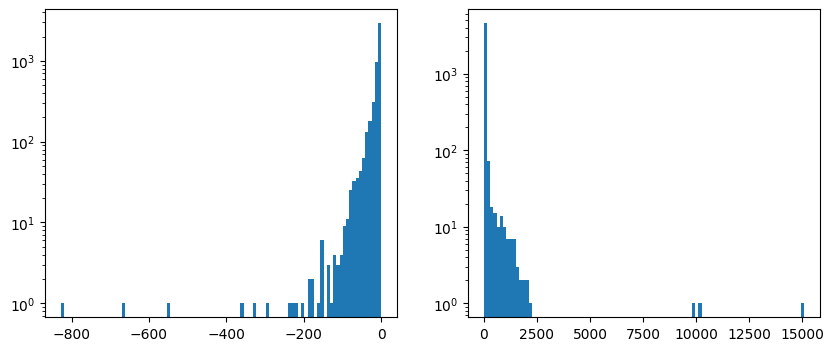

In [12]:
fig, axs = plt.subplots(1,2, figsize=(10, 4))
axs[0].hist(min_values, bins = 100)
axs[1].hist(max_values, bins = 100)
axs[0].set_yscale("log")
axs[1].set_yscale("log")

plt.show()

In [16]:
X_dmso = df.loc[dmso_mask, feature_cols]
X_dmso.describe()

,Cells_AreaShape_Area,Cells_AreaShape_BoundingBoxArea,Cells_AreaShape_BoundingBoxMaximum_X,Cells_AreaShape_BoundingBoxMaximum_Y,Cells_AreaShape_BoundingBoxMinimum_X,Cells_AreaShape_BoundingBoxMinimum_Y,Cells_AreaShape_Center_X,Cells_AreaShape_Center_Y,Cells_AreaShape_Compactness,Cells_AreaShape_Eccentricity,...,Nuclei_Texture_Variance_RNA_10_02_256,Nuclei_Texture_Variance_RNA_10_03_256,Nuclei_Texture_Variance_RNA_3_00_256,Nuclei_Texture_Variance_RNA_3_01_256,Nuclei_Texture_Variance_RNA_3_02_256,Nuclei_Texture_Variance_RNA_3_03_256,Nuclei_Texture_Variance_RNA_5_00_256,Nuclei_Texture_Variance_RNA_5_01_256,Nuclei_Texture_Variance_RNA_5_02_256,Nuclei_Texture_Variance_RNA_5_03_256
count,1.280000e+02,1.280000e+02,1.280000e+02,1.280000e+02,1.280000e+02,1.280000e+02,1.280000e+02,128.000000,1.280000e+02,1.280000e+02,...,1.280000e+02,1.280000e+02,1.280000e+02,1.280000e+02,1.280000e+02,1.280000e+02,1.280000e+02,128.000000,1.280000e+02,1.280000e+02
mean,9.313226e-09,2.421439e-08,-1.490116e-08,1.490116e-08,1.490116e-08,2.980232e-08,-2.980232e-08,0.000000,7.450581e-09,7.450581e-09,...,7.450581e-09,-7.450581e-09,1.490116e-08,-1.490116e-08,7.450581e-09,-7.450581e-09,2.235174e-08,0.000000,-2.980232e-08,-1.490116e-08
std,1.003929e+00,1.003929e+00,1.003929e+00,1.003929e+00,1.003929e+00,1.003929e+00,1.003929e+00,1.003929,1.003929e+00,1.003929e+00,...,1.003929e+00,1.003929e+00,1.003929e+00,1.003929e+00,1.003929e+00,1.003929e+00,1.003929e+00,1.003929,1.003929e+00,1.003929e+00
min,-2.915330e+00,-2.756475e+00,-1.664693e+00,-3.519205e+00,-1.928438e+00,-3.310805e+00,-1.798679e+00,-3.427104,-2.252612e+00,-2.648372e+00,...,-1.698313e+00,-1.758280e+00,-1.745878e+00,-1.746255e+00,-1.750556e+00,-1.746548e+00,-1.730247e+00,-1.733389,-1.733637e+00,-1.754140e+00
25%,-6.224402e-01,-6.395937e-01,-7.915394e-01,-8.274697e-01,-7.702146e-01,-8.255397e-01,-7.790998e-01,-0.817192,-6.746884e-01,-7.045549e-01,...,-7.275790e-01,-7.180668e-01,-7.344168e-01,-7.389910e-01,-7.262367e-01,-7.234198e-01,-7.431760e-01,-0.728219,-7.177780e-01,-7.311777e-01
50%,-6.812707e-02,-9.058445e-02,-9.331007e-03,-4.482633e-04,-3.567431e-02,-2.090452e-02,-2.418415e-02,0.020399,-7.273419e-02,-3.578412e-02,...,-1.665313e-01,-1.424736e-01,-1.316645e-01,-1.159179e-01,-1.415778e-01,-1.520529e-01,-1.466890e-01,-0.157825,-1.363294e-01,-1.506324e-01
75%,6.317214e-01,6.800065e-01,7.785780e-01,6.835857e-01,8.236154e-01,6.867986e-01,8.147334e-01,0.675585,6.640533e-01,6.614429e-01,...,6.059439e-01,6.303768e-01,6.055535e-01,6.153438e-01,6.296169e-01,6.088992e-01,5.920153e-01,0.596181,6.244480e-01,6.131190e-01
max,2.475767e+00,2.546504e+00,2.064958e+00,2.229349e+00,2.019933e+00,2.332539e+00,2.048690e+00,2.284371,2.617593e+00,2.803230e+00,...,3.522426e+00,3.605244e+00,3.457827e+00,3.368463e+00,3.327317e+00,3.375398e+00,3.459853e+00,3.354545,3.399469e+00,3.517901e+00


In [19]:
# 1. Load data
df = pd.read_parquet(
    "/scratch/work/masooda1/datasets/mocop/"
    "source_1.Batch1_20221004.UL001641.UL001641.parquet"
)

# 2. Select features and DMSO subset
feature_cols = [col for col in df.columns if not col.startswith("Metadata_")]
dmso_mask = df.Metadata_InChI == "InChI=1S/C2H6OS/c1-4(2)3/h1-2H3"
X_dmso = df.loc[dmso_mask, feature_cols]
X_dmso.describe()

,Cells_AreaShape_Area,Cells_AreaShape_BoundingBoxArea,Cells_AreaShape_BoundingBoxMaximum_X,Cells_AreaShape_BoundingBoxMaximum_Y,Cells_AreaShape_BoundingBoxMinimum_X,Cells_AreaShape_BoundingBoxMinimum_Y,Cells_AreaShape_Center_X,Cells_AreaShape_Center_Y,Cells_AreaShape_Compactness,Cells_AreaShape_Eccentricity,...,Nuclei_Texture_Variance_RNA_10_02_256,Nuclei_Texture_Variance_RNA_10_03_256,Nuclei_Texture_Variance_RNA_3_00_256,Nuclei_Texture_Variance_RNA_3_01_256,Nuclei_Texture_Variance_RNA_3_02_256,Nuclei_Texture_Variance_RNA_3_03_256,Nuclei_Texture_Variance_RNA_5_00_256,Nuclei_Texture_Variance_RNA_5_01_256,Nuclei_Texture_Variance_RNA_5_02_256,Nuclei_Texture_Variance_RNA_5_03_256
count,128.000000,128.000000,128.000000,128.000000,128.000000,128.000000,128.000000,128.000000,128.000000,128.000000,...,128.000000,128.000000,128.000000,128.000000,128.000000,128.000000,128.000000,128.000000,128.000000,128.000000
mean,3947.111816,7378.476562,590.338196,563.877991,505.366760,479.144653,547.310608,521.096252,2.004766,0.767194,...,89.788269,93.693840,88.119232,86.584442,87.799530,86.592270,86.604378,86.742966,86.338196,86.768066
std,262.476898,522.848083,34.772041,28.997278,34.523998,28.559452,34.689251,28.730270,0.031271,0.008114,...,11.549129,11.914387,11.294264,11.163174,11.360028,11.146830,11.141078,11.242851,11.231534,11.247273
min,3184.899902,5942.899902,532.679993,462.230011,439.049988,384.959991,485.160004,423.019989,1.934600,0.745790,...,70.250999,72.827003,68.477997,67.167000,67.990997,67.199997,67.403000,67.331001,66.943001,67.115997
25%,3784.375000,7045.375122,562.922485,539.977509,478.879990,455.660004,520.390015,497.709999,1.983750,0.761500,...,81.418251,85.172003,79.857000,78.367249,79.581753,78.559998,78.356998,78.587749,78.308001,78.576502
50%,3929.299927,7331.300049,590.015015,563.865021,504.139999,478.550003,546.474976,521.680023,2.002500,0.766905,...,87.872501,92.003002,86.638000,85.295498,86.197498,84.903999,84.976498,84.975502,84.813000,85.080498
75%,4112.275024,7732.625122,617.304993,583.622513,533.690002,498.682510,575.462494,540.430008,2.025450,0.772540,...,96.758999,101.175001,94.931747,93.426748,94.924002,93.353003,93.174250,93.419498,93.324253,93.636997
max,4594.399902,8704.700195,661.859985,628.270020,574.830017,545.500000,618.099976,586.469971,2.086300,0.789850,...,130.309998,136.479996,127.019997,124.040001,125.449997,124.070000,125.000000,124.309998,124.370003,126.180000


In [36]:
columns_with_highest_std = X_dmso.std().reset_index(name = "feature_std").sort_values(by = "feature_std").tail(20)["index"].tolist()
X_dmso[columns_with_highest_std]

,Image_Intensity_TotalIntensity_AGP__BackgroundOnly,Image_Intensity_TotalIntensity_DNA_BackgroundOnly,Image_Intensity_TotalIntensity_DNA,Image_Intensity_TotalIntensity_Mito_BackgroundOnly,Image_Intensity_TotalIntensity_RNA_BackgroundOnly,Image_ImageQuality_TotalIntensity_OrigDNA,Image_Intensity_TotalIntensity_ER__BackgroundOnly,Image_Intensity_TotalIntensity_AGP,Image_ImageQuality_TotalIntensity_OrigAGP,Image_Intensity_TotalIntensity_ER,Image_Intensity_TotalIntensity_RNA,Image_Intensity_TotalIntensity_Mito,Image_ImageQuality_TotalIntensity_OrigER,Image_ImageQuality_TotalIntensity_OrigMito,Image_ImageQuality_TotalIntensity_OrigRNA,Image_Intensity_TotalArea_AGP__BackgroundOnly,Image_Intensity_TotalArea_ER__BackgroundOnly,Image_Intensity_TotalArea_RNA_BackgroundOnly,Image_Intensity_TotalArea_DNA_BackgroundOnly,Image_Intensity_TotalArea_Mito_BackgroundOnly
380,3278.600098,3165.199951,13452.0,7547.899902,8459.700195,19840.0,9774.599609,26657.0,56023.0,82651.0,93505.0,83626.0,186740.0,143430.0,201710.0,500950.0,500950.0,500950.0,500950.0,500950.0
381,2328.800049,1991.699951,16409.0,6008.000000,6292.000000,24326.0,6911.200195,34364.0,73454.0,104120.0,125100.0,113980.0,238490.0,197740.0,274730.0,304090.0,304090.0,304090.0,304090.0,304090.0
382,4038.800049,3759.899902,14278.0,9114.799805,10167.000000,21127.0,11992.000000,28846.0,61156.0,86888.0,99009.0,91601.0,195490.0,156120.0,212000.0,542040.0,542040.0,542040.0,542040.0,542040.0
383,4042.199951,3873.100098,13170.0,8980.099609,10106.000000,19518.0,12219.000000,25293.0,53778.0,79421.0,85227.0,77760.0,181540.0,134600.0,185470.0,557150.0,557150.0,557150.0,557150.0,557150.0
384,2211.500000,2000.300049,14722.0,5575.700195,5811.700195,21739.0,6606.100098,30714.0,65853.0,98881.0,111560.0,108270.0,229410.0,187530.0,245670.0,315130.0,315130.0,315130.0,315130.0,315130.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
503,2881.000000,2931.199951,15010.0,5755.799805,7596.500000,22349.0,8722.099609,28805.0,61828.0,88771.0,101900.0,78729.0,205280.0,136870.0,224400.0,429180.0,429180.0,429180.0,429180.0,429180.0
504,2219.699951,1971.599976,15822.0,4834.799805,5735.200195,23300.0,6424.100098,33088.0,70071.0,102780.0,119740.0,94153.0,236050.0,163140.0,261630.0,314340.0,314340.0,314340.0,314340.0,314340.0
505,2092.399902,1660.599976,15390.0,4346.399902,5459.600098,22828.0,5811.299805,32647.0,70093.0,99698.0,114860.0,83391.0,230870.0,145460.0,253840.0,259620.0,259620.0,259620.0,259620.0,259620.0
506,2718.100098,2701.300049,14873.0,4960.299805,7056.100098,22187.0,8128.200195,29934.0,65532.0,91178.0,104050.0,73349.0,213530.0,129110.0,232690.0,397080.0,397080.0,397080.0,397080.0,397080.0


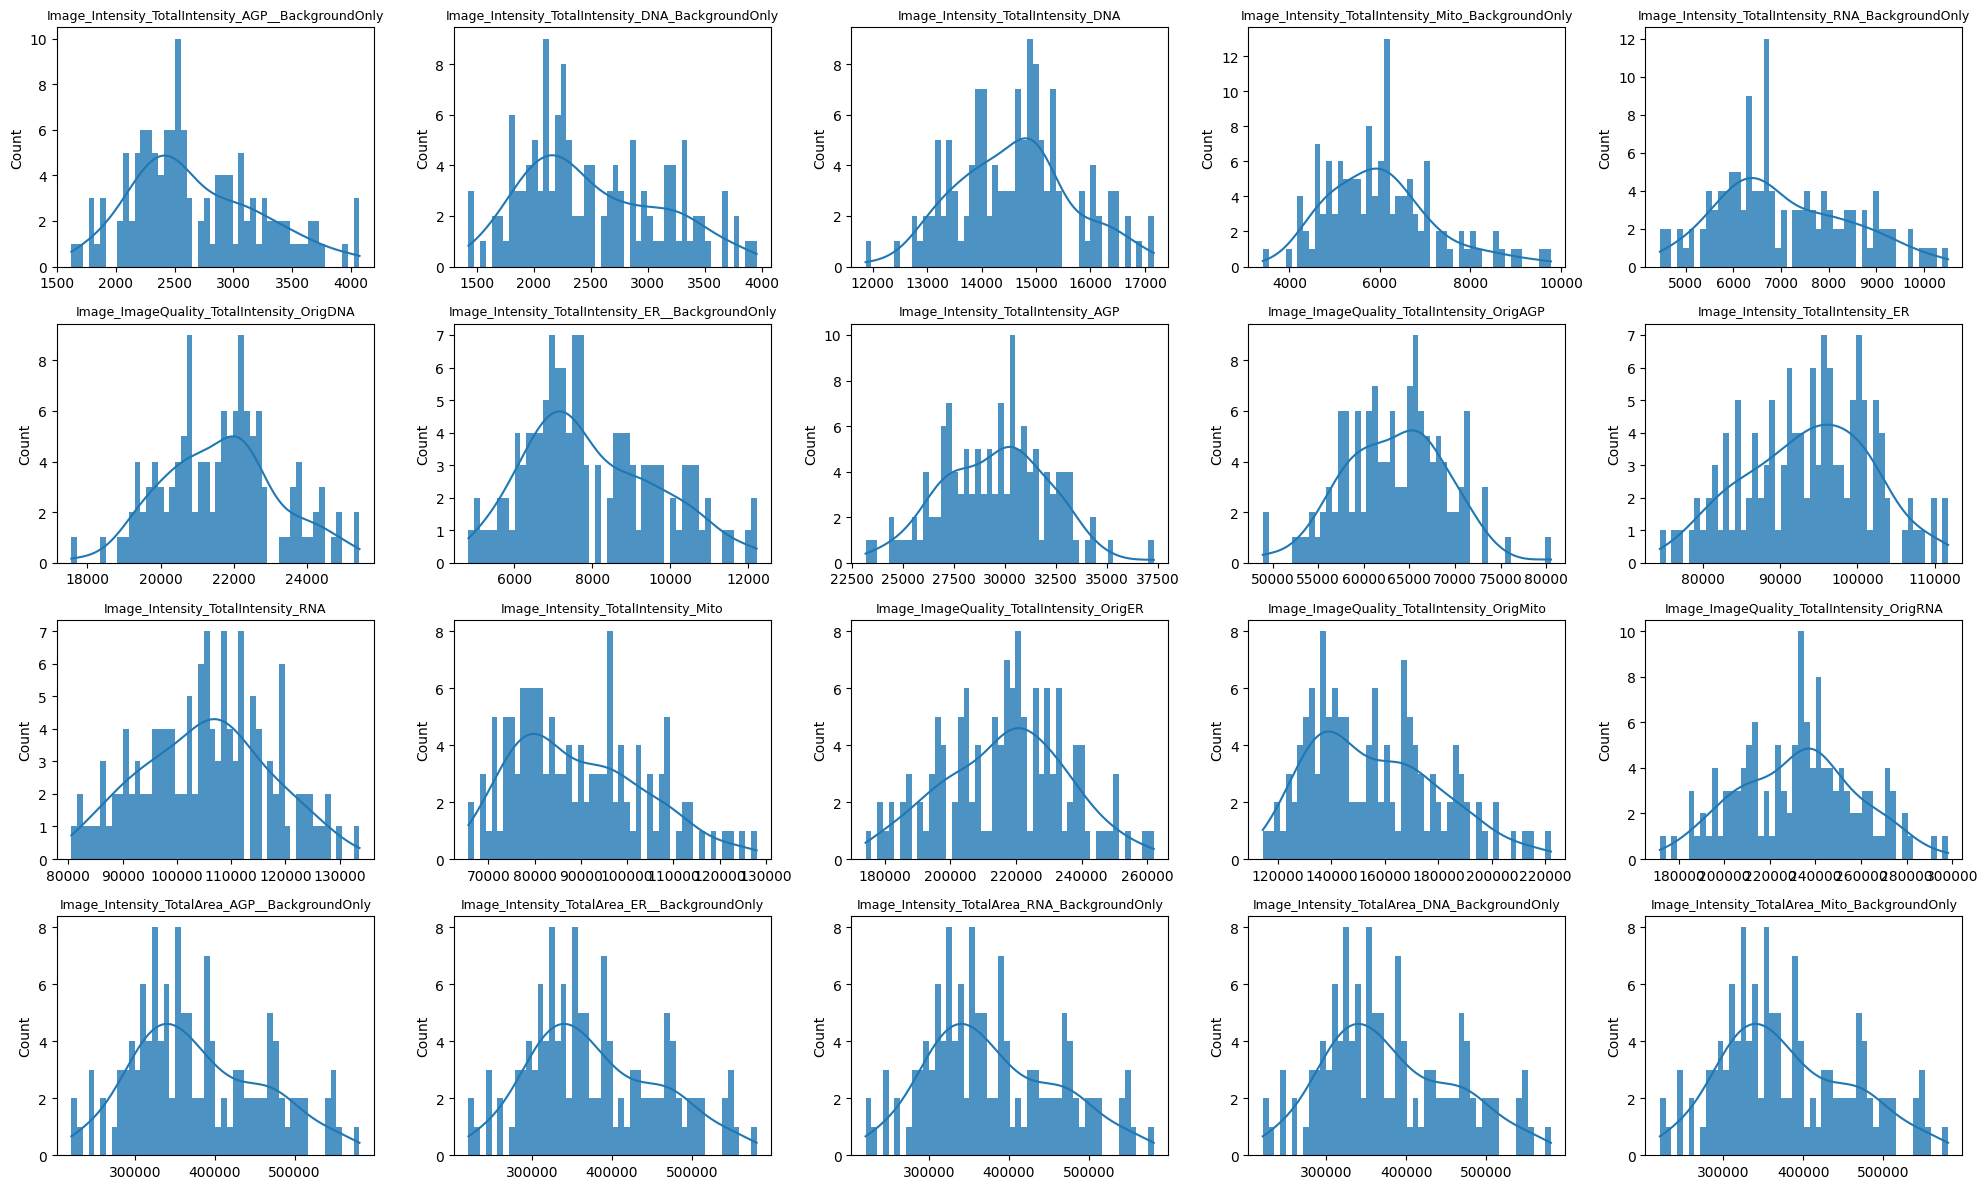

In [44]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ───────────────────────────────
# 1.  Load the plate and isolate DMSO
# ───────────────────────────────
df = pd.read_parquet(
    "/scratch/work/masooda1/datasets/mocop/source_1.Batch1_20221004.UL001641.UL001641.parquet"
)
feature_cols = [c for c in df.columns if not c.startswith("Metadata_")]

dmso_mask = df["Metadata_InChI"] == "InChI=1S/C2H6OS/c1-4(2)3/h1-2H3"
X_dmso   = df.loc[dmso_mask, feature_cols]

# ───────────────────────────────
# 2.  Identify the 20 highest‑σ features
# ───────────────────────────────
columns_with_highest_std = (
    X_dmso.std()
         .sort_values()
         .tail(20)
         .index
         .tolist()
)

# ───────────────────────────────
# 3.  Plot distograms in a 4×5 grid
# ───────────────────────────────
n_rows, n_cols = 4, 5
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*4, n_rows*3), sharex=False)
axes = axes.flatten()

for ax, col in zip(axes, columns_with_highest_std):
    sns.histplot(
        X_dmso[col], bins=50, kde=True, ax=ax, linewidth=0, alpha=0.8
    )
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("")
    ax.set_ylabel("Count")

# If you have fewer than 20 features for some reason, hide empty panels
for empty_ax in axes[len(columns_with_highest_std):]:
    empty_ax.set_visible(False)

plt.tight_layout()
fig.savefig("/scratch/work/masooda1/mocop/Figures/Data_plots/DMSO_features.png",
            dpi = 300)
plt.show()

In [ ]:
# drop features with only low variance 


# Dataloader for VAE

In [1]:
import os
import sys
sys.path.append('/scratch/work/masooda1/Multi_Modal_Contrastive')

import torch
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader, Subset
from train_vae import JUMPDataModule
from mocop.training import build_dataloaders

[neptune] [warning] NeptuneDeprecationWarning: The 'neptune-client' package has been deprecated and will be removed in the future. Install the 'neptune' package instead. For more, see https://docs-legacy.neptune.ai/setup/upgrading/
[neptune] [warning] NeptuneDeprecationWarning: You're importing the Neptune client library via the deprecated `neptune.new` module, which will be removed in a future release. Import directly from `neptune` instead.


In [2]:
# --- Configuration ---
data_path = "/scratch/work/masooda1/Multi_Modal_Contrastive/data/dummy_data/cell_fetures_with_smiles_2000.parquet"
PAD_LENGTH = 250
BATCH_SIZE = 4
NUM_WORKERS = 1
NORMALIZE = False
SEED = 42 # The master seed for the experiment

splits = {"train":"/scratch/work/masooda1/Multi_Modal_Contrastive/data/dummy_data/jump-compound-split-0-train.csv",
          "val":"/scratch/work/masooda1/Multi_Modal_Contrastive/data/dummy_data/jump-compound-split-0-val.csv"}

# --- 2. Instantiate the Dataset ---
print("\nInitializing full dataset...")

data_module = JUMPDataModule(
        data_path=data_path,
        splits=splits,
        batch_size=BATCH_SIZE,
        normalize=NORMALIZE,
        num_workers=NUM_WORKERS,
        random_seed=SEED,
    )


Initializing full dataset...


In [3]:
# Prepare data to get feature dimension
data_module.prepare_data()
data_module.setup()

Setting up JUMP data module...
Loading data from /scratch/work/masooda1/Multi_Modal_Contrastive/data/dummy_data/cell_fetures_with_smiles_2000.parquet
Loaded dataframe with shape: (17764, 4716)
Feature columns: 4709
Dataset created with 2000 unique molecules
Split train: /scratch/work/masooda1/Multi_Modal_Contrastive/data/dummy_data/jump-compound-split-0-train.csv
Split val: /scratch/work/masooda1/Multi_Modal_Contrastive/data/dummy_data/jump-compound-split-0-val.csv

Dataloader Sizes:
--------------------------------------------------
TRAIN:
  • Number of samples: 1800
  • Batch size: 4
  • Number of batches: 450
  • Drop last: True
--------------------------------------------------
VAL:
  • Number of samples: 100
  • Batch size: 4
  • Number of batches: 25
  • Drop last: False
--------------------------------------------------
Data module setup complete. Feature dimension: 4709


In [22]:
batch = next(iter(data_module.val_dataloader()))

SMILES: CC(=O)N1c2c(C)ccc(C)c2-c2ccccc2S1(=O)=O, total samples: 4
SMILES: Cc1cc(C(=O)NCc2ccc(Cl)cc2)c2c(C)nn(-c3ccccc3Cl)c2n1, total samples: 4
SMILES: CC(=O)c1ccc(F)c(-c2cc(C)cc3c2OC(CN=C(O)C2CCC2)C3)c1, total samples: 5
SMILES: COc1ccc(-n2c(N)c(C(O)=NC3CCCC3)c3nc4ccccc4nc32)cc1Cl, total samples: 5
SMILES: COc1ccc2nnc(CN=C(O)CC3CC3)n2n1, total samples: 4
SMILES: Cc1nccn1-c1cc(N2CCN(C(=O)C(c3ccccc3)c3ccccc3)CC2)ncn1, total samples: 5
SMILES: O=C(c1cc(F)cc(F)c1)N1CCCC1c1nccnc1-c1ncc[nH]1, total samples: 6
SMILES: COc1cc(C=NNc2nc(C)cc(O)n2)ccc1O, total samples: 4


In [23]:
batch

tensor([[-0.7498, -0.7384,  0.6256,  ..., -0.8093, -0.8204, -0.8162],
        [-0.6679, -0.7684,  0.0033,  ..., -0.6091, -0.5889, -0.5950],
        [-2.1160, -2.6229, -0.4438,  ..., -0.7919, -0.8170, -0.8555],
        [ 1.6192,  1.1605,  0.0820,  ..., -0.1212, -0.1268, -0.1141]])

In [1]:
import pandas as pd

,index,min_values
84,Cells_Correlation_Manders_AGP_DNA,0.013988
3637,Nuclei_Correlation_Manders_DNA_ER,0.037923
3646,Nuclei_Correlation_Manders_Mito_ER,0.043411
3633,Nuclei_Correlation_Manders_AGP_ER,0.046782
3650,Nuclei_Correlation_Manders_RNA_ER,0.059290
...,...,...
2433,Cytoplasm_Texture_Variance_DNA_5_01_256,133.267456
2366,Cytoplasm_Texture_SumVariance_DNA_10_02_256,133.274841
2426,Cytoplasm_Texture_Variance_DNA_10_02_256,133.275467
1766,Cytoplasm_Texture_Contrast_DNA_10_02_256,133.275726


In [13]:
controls = pd.read_csv("/scratch/work/masooda1/Multi_Modal_Contrastive/data/jump_data/jump_controls.csv")
controls

FileNotFoundError: [Errno 2] No such file or directory: '/scratch/work/masooda1/Multi_Modal_Contrastive/data/jump_data/jump_controls.csv'

In [1]:
import pandas as pd

In [2]:
# Positive and negative controls
positive_controls = {
    'IBCXZJCWDGCXQT-UHFFFAOYSA-N': 1593,
    'IHLVSLOZUHKNMQ-UHFFFAOYSA-N': 5881,
    'SRVFFFJZQVENJC-UHFFFAOYSA-N': 7059,
    'CQKBSRPVZZLCJE-UHFFFAOYSA-N': 7443,
    'KPBNHDGDUADAGP-UHFFFAOYSA-N': 7454,
    'GJFCONYVAUNLKB-UHFFFAOYSA-N': 7459,
    'LOUPRKONTZGTKE-UHFFFAOYSA-N': 7459,
    'OINGHOPGNMYCAB-UHFFFAOYSA-N': 7461,
    'IVUGFMLRJOCGAS-UHFFFAOYSA-N': 7469,
    'IAZDPXIOMUYVGZ-UHFFFAOYSA-N': 79094
}
positive_controls = pd.DataFrame(list(positive_controls.items()), columns=['Metadata_InChIKey', 'duplicates'])

data_path = "/scratch/work/masooda1/Multi_Modal_Contrastive/data/dummy_data/cell_fetures_with_smiles_2000.parquet"
data = pd.read_parquet(data_path)
data = data[~data.Metadata_InChIKey.isin(positive_controls.Metadata_InChIKey)]


In [4]:
df = data.iloc[:,7:]

z_scaled = df.copy()
for column in z_scaled.columns:
    z_scaled[column] = (z_scaled[column] - z_scaled[column].mean()) / z_scaled[column].std()

z_scaled.min().reset_index(name = "min_values").sort_values(by = "min_values")

,index,min_values
2066,Cytoplasm_Texture_InfoMeas1_DNA_10_02_256,-101.260696
1338,Cytoplasm_Correlation_Manders_ER_DNA,-101.225426
4304,Nuclei_Texture_InfoMeas1_DNA_10_03_256,-101.188744
4302,Nuclei_Texture_InfoMeas1_DNA_10_01_256,-100.992569
1329,Cytoplasm_Correlation_Manders_AGP_DNA,-100.829140
...,...,...
541,Cells_Texture_Contrast_DNA_10_03_256,-0.010359
2366,Cytoplasm_Texture_SumVariance_DNA_10_02_256,-0.010014
2426,Cytoplasm_Texture_Variance_DNA_10_02_256,-0.009982
1766,Cytoplasm_Texture_Contrast_DNA_10_02_256,-0.009974


In [9]:
data.isnull().sum().sum()

0

# Reading Cell painting, LINCS and activity data

In [23]:
import numpy as np
import pandas as pd

In [24]:
data_dir = "/scratch/work/masooda1/Multi_Modal_Contrastive/puma_data/feature_data/"
cp = np.load(data_dir + "cp.npz")
cp = pd.DataFrame(cp["features"])
cp

,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
0,0.438931,0.339180,0.472916,0.475541,0.570592,0.482846,0.448275,0.574725,0.336214,0.508167,...,1.593061e-17,5.766101e-14,2.957989e-11,0.168378,0.16738,1.481515e-18,2.324150e-16,4.703598e-08,0.166633,0.490864
1,0.536747,0.281884,0.161372,0.128038,0.096592,0.177154,0.151731,0.106018,0.157225,0.098896,...,1.593061e-17,5.766101e-14,2.957989e-11,0.168378,0.16738,1.481515e-18,2.324150e-16,4.703598e-08,1.000000,0.748161
2,0.508510,0.371799,0.256340,0.348955,0.295915,0.337973,0.436038,0.355568,0.417761,0.310363,...,1.593061e-17,5.766101e-14,2.957989e-11,0.168378,0.16738,1.481515e-18,2.324150e-16,4.703598e-08,0.166633,0.799647
3,0.612653,0.732698,0.618773,0.605758,0.740947,0.629302,0.557772,0.641081,0.478595,0.591822,...,1.593061e-17,5.766101e-14,2.957989e-11,0.168378,0.16738,1.481515e-18,2.324150e-16,4.703598e-08,0.166633,0.116146
4,0.289790,0.524736,0.506943,0.442711,0.388346,0.525380,0.430205,0.349974,0.422437,0.314654,...,1.593061e-17,5.766101e-14,2.957989e-11,0.168378,0.16738,1.481515e-18,2.324150e-16,4.703598e-08,1.000000,0.830065
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16973,0.000020,0.995416,0.989971,0.990129,0.989731,0.991142,0.990038,0.988331,0.986982,0.981787,...,1.593061e-17,5.766101e-14,2.957989e-11,0.168378,0.16738,1.481515e-18,2.324150e-16,4.703598e-08,0.166633,0.057191
16974,0.000020,0.998878,0.994878,0.995683,0.995676,0.995799,0.996388,0.996254,0.996107,0.994667,...,1.593061e-17,5.766101e-14,2.957989e-11,0.168378,0.16738,1.481515e-18,2.324150e-16,4.703598e-08,0.166633,0.059936
16975,0.000020,0.998878,0.994878,0.995683,0.995676,0.995799,0.996388,0.996254,0.996107,0.994667,...,1.593061e-17,5.766101e-14,2.957989e-11,0.168378,0.16738,1.481515e-18,2.324150e-16,4.703598e-08,0.166633,0.059936
16976,0.000020,0.999968,0.997019,0.996296,0.996317,0.997452,0.996088,0.995898,0.994433,0.992323,...,1.593061e-17,5.766101e-14,2.957989e-11,0.168378,0.16738,1.481515e-18,2.324150e-16,4.703598e-08,0.166633,0.026496


In [25]:
ge = np.load(data_dir + "ge.npz")
print(ge.files)
ge = pd.DataFrame(ge["features"])
ge

['features']


,0,1,2,3,4,5,6,7,8,9,...,967,968,969,970,971,972,973,974,975,976
0,-98.179573,-18.063766,-69.651962,-73.376541,25.668484,123.791733,104.189194,-167.647507,10.331034,134.568527,...,-86.313896,146.107330,-64.326759,86.650932,22.519251,-14.762053,-23.469042,-108.444473,61.957390,-88.639954
1,113.980865,107.591560,-56.803543,-73.413788,-21.302086,45.411346,-30.689367,64.942673,-105.347733,-59.277039,...,36.842381,38.187866,3.722266,-16.922020,76.019249,-19.585550,-61.470230,29.303247,-26.217403,-92.032776
2,20.413273,-47.693810,108.411919,20.655867,-116.272102,35.430580,-111.371902,-41.029301,-39.562798,-15.996061,...,-34.347160,-60.731422,-49.558777,-97.926163,143.044281,-200.386459,107.046188,-39.623974,143.648605,78.426064
3,162.391647,-64.405952,-36.244629,24.017542,13.573824,-33.961510,-31.668892,54.797810,31.534136,57.929176,...,4.542232,53.842461,95.738976,-28.019667,66.711609,-6.386764,-81.554420,49.349693,36.477169,-63.946724
4,-19.889879,-63.710075,-136.305313,93.834297,11.443810,90.473259,-43.126507,-12.950891,79.967644,68.428596,...,-13.323322,123.762848,-238.504318,-80.629318,218.027313,2.613670,-82.447655,29.088800,-39.129089,-52.153690
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16973,99.690117,-1.513627,10.696726,169.014008,-151.466949,44.483704,54.408169,20.991964,-81.478348,43.528885,...,18.087219,-104.191383,-195.294266,-79.982620,213.761765,-109.527924,-17.761009,-126.083878,31.419495,52.532913
16974,-146.198196,103.915154,-70.538887,-51.071243,-56.040257,133.805359,122.616875,-55.982166,-204.099854,98.320358,...,-152.754944,11.881421,-138.668900,-22.582922,-44.111012,20.604040,34.471054,-182.495041,162.361252,-1.797441
16975,-24.534241,108.468094,-148.908310,-29.814344,-13.425154,90.293320,41.180645,-38.450443,-95.808189,139.041702,...,-230.376740,37.328518,-12.381166,36.234001,-149.129379,47.599846,163.762787,65.628448,60.210217,-28.427923
16976,-149.355942,71.448860,33.385715,-0.037508,-95.311859,3.351213,-50.910465,1.000013,-21.122631,-18.767120,...,-23.876122,-64.176178,75.887070,-54.085777,44.964363,67.817795,43.003979,-34.102062,-7.703662,-83.478592


In [18]:
ge_scaled = np.load(data_dir + "ge_scaled.npz")
print(ge_scaled.files)
ge_scaled = pd.DataFrame(ge_scaled["features"])
ge_scaled

['features']


,0,1,2,3,4,5,6,7,8,9,...,967,968,969,970,971,972,973,974,975,976
0,-1.069867,-0.212797,-0.687068,-0.778230,0.324971,1.260833,0.963676,-1.837139,0.176536,1.336040,...,-0.907679,1.628378,-0.551136,0.968724,0.231786,-0.122078,-0.264736,-1.103552,0.645920,-0.928843
1,1.295029,1.091038,-0.546547,-0.778626,-0.199076,0.401292,-0.420458,0.744082,-1.106996,-0.677826,...,0.484615,0.421767,0.182880,-0.132600,0.793230,-0.174316,-0.687191,0.385583,-0.338655,-0.965995
2,0.252056,-0.520247,1.260398,0.221475,-1.258649,0.291841,-1.248428,-0.431966,-0.377069,-0.228179,...,-0.320189,-0.684215,-0.391840,-0.993944,1.496611,-2.132385,1.186185,-0.359561,1.558098,0.900570
3,1.834651,-0.693657,-0.321696,0.257214,0.190032,-0.469132,-0.430510,0.631497,0.411798,0.539832,...,0.119459,0.596796,1.175425,-0.250605,0.695553,-0.031374,-0.910464,0.602296,0.361403,-0.658446
4,-0.197192,-0.686436,-1.416049,0.999470,0.166268,0.895453,-0.548088,-0.120359,0.949200,0.648911,...,-0.082513,1.378552,-2.429916,-0.810021,2.283504,0.066101,-0.920394,0.383264,-0.482829,-0.529310
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16973,1.135734,-0.041068,0.191697,1.798742,-1.651316,0.391120,0.452819,0.256329,-0.842150,0.390227,...,0.272586,-1.170126,-1.963827,-0.803144,2.238740,-1.148390,-0.201281,-1.294244,0.304928,0.617034
16974,-1.605117,1.052890,-0.696769,-0.541091,-0.586647,1.370645,1.152782,-0.597908,-2.202716,0.959457,...,-1.658801,0.127644,-1.353033,-0.192795,-0.467452,0.260936,0.379376,-1.904082,1.767047,0.022103
16975,-0.248962,1.100133,-1.553887,-0.315099,-0.111194,0.893480,0.317078,-0.403346,-1.001149,1.382512,...,-2.536323,0.412159,0.009179,0.432625,-1.569545,0.553300,1.816696,0.778279,0.626411,-0.269507
16976,-1.640316,0.716011,0.439844,0.001473,-1.024797,-0.059950,-0.627968,0.034464,-0.172463,-0.256967,...,-0.201813,-0.722730,0.961291,-0.527775,0.467331,0.772259,0.474236,-0.299866,-0.131928,-0.872325


In [19]:
mo = np.load(data_dir + "mo.npz")
print(mo.files)
mo = pd.DataFrame(mo["features"])
mo

['features']


,0,1,2,3,4,5,6,7,8,9,...,1711,1712,1713,1714,1715,1716,1717,1718,1719,1720
0,0.591721,-0.168389,-0.037824,1.152953,1.108924,-0.938964,0.009324,0.700305,0.599502,0.472432,...,-0.366809,-0.119443,-0.175968,-0.084259,0.222051,0.064224,0.114876,-0.015781,-0.076690,0.050786
1,0.446364,0.491192,0.832862,0.584370,0.738108,-0.251659,0.055885,0.467414,0.466488,0.574501,...,-0.066777,0.232607,0.104614,0.291612,0.718555,0.714358,0.624505,-0.066481,-0.096030,-0.187823
2,0.839044,0.639029,-0.854093,2.693490,2.240741,-1.803887,-0.297484,1.449060,1.403063,0.379552,...,-0.537196,-0.713205,-0.839357,-0.843473,-0.316524,-0.339358,-0.279977,-0.218260,-0.571646,-0.473216
3,2.076383,0.036309,-0.708978,2.399896,2.147060,-1.034697,-0.368985,2.089781,2.080975,1.485956,...,-0.847180,-0.601978,-0.974564,-0.874023,-1.791852,-1.961258,-1.872804,0.366205,-0.184731,-0.047909
4,0.700196,-0.111528,1.340763,-1.086228,-0.863645,1.883548,0.373472,0.292832,0.249604,1.121634,...,-0.165989,1.610032,1.812533,1.661981,0.587454,0.669715,0.801128,0.100790,0.139663,0.019859
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16973,-0.621753,0.536680,0.470076,-0.076902,-0.259122,0.240557,0.130043,-0.599421,-0.528979,-0.555683,...,0.161839,0.538289,0.497975,0.511640,-0.955127,-0.994228,-1.026504,-0.460480,-0.449167,-0.479131
16974,-0.598974,0.343355,0.542634,-0.559450,-0.464712,0.650230,0.073209,-0.609514,-0.557058,-0.532474,...,0.205787,0.721797,0.530897,0.715500,-0.466048,-0.664316,-0.617057,-0.614048,-0.323177,-0.381081
16975,-0.263063,0.388843,0.052872,-0.281266,-0.532503,0.178342,0.478055,-0.418908,-0.406390,-0.174031,...,0.702832,1.018956,1.221279,1.133012,-0.670355,-1.060854,-0.995681,-0.461332,-0.604991,-0.521853
16976,-0.459764,-0.543667,0.361241,-0.124684,0.346285,0.464289,0.231007,-0.371306,-0.409049,-0.411748,...,1.128770,0.189264,0.977442,0.636972,-0.617795,-0.739473,-0.696907,-0.501404,-0.482858,-0.414342


In [20]:
mobc = np.load(data_dir + "mobc.npz")
print(mobc.files)
mobc = pd.DataFrame(mobc["features"])
mobc

['features']


,0,1,2,3,4,5,6,7,8,9,...,1736,1737,1738,1739,1740,1741,1742,1743,1744,1745
0,-0.358398,1.110351,-0.644217,1.005610,0.536393,-0.484223,0.695963,-0.402000,0.575984,-0.261963,...,-0.490481,-0.377669,0.262304,-0.839946,-0.015254,0.043836,0.587711,-1.350084,-0.010239,-0.124908
1,0.081977,-0.670284,0.153843,0.070386,-0.266596,-0.767235,0.285579,-0.753169,0.084714,0.883861,...,-0.055604,-0.393623,0.475551,0.403581,0.049612,0.404363,0.889808,0.695071,-0.696030,-0.030113
2,0.321720,-0.072824,-1.710102,0.658229,0.300622,-1.258078,0.006987,-0.559849,0.004051,0.908019,...,-0.360307,-1.619196,0.328462,-1.146476,0.677876,0.175886,-0.067504,0.060738,-0.264318,-0.311633
3,0.133564,-0.421580,0.117730,0.460650,1.450245,-0.365821,-0.082180,-2.443276,0.384857,0.518164,...,-0.821793,0.820198,0.187455,0.063782,-0.080191,0.558027,-1.786899,0.002514,0.977796,0.480826
4,1.438583,-1.215223,-1.015127,0.110274,-0.440371,3.547475,1.616346,-0.916270,-1.299005,0.769253,...,-0.446909,-2.926935,2.028635,-0.445259,-0.536417,3.052995,1.533814,0.444330,-0.583476,0.589822
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16973,-0.155980,0.079962,-0.260621,0.821556,-0.259298,0.681164,-1.367858,-0.084059,-0.165947,0.219564,...,-0.128927,0.034343,-0.183663,1.012144,0.482618,-0.120309,-0.054456,0.070896,0.196710,0.364737
16974,1.033347,0.409676,-0.474806,-0.977037,0.396328,-0.781659,-0.225464,-0.882892,-0.561938,0.853402,...,-0.147362,-0.238905,0.180870,0.230390,0.242799,0.419582,0.659223,-0.818153,-0.068555,0.165044
16975,0.340503,0.627831,-1.020360,-0.606005,-0.813410,0.051395,-1.209996,0.280195,0.101819,-0.278648,...,-0.000183,-0.169376,0.845434,0.214150,0.295777,-0.417044,-0.174177,0.466798,-0.643462,0.356486
16976,-0.203781,-0.216424,-0.802300,-0.599200,0.248239,-0.066688,-1.050070,0.285051,0.245888,-0.039042,...,0.073676,0.444016,0.226752,0.417272,0.185643,0.063225,-0.456790,0.837518,-0.312459,0.902576


In [21]:
# misc data
misc_dir = "/scratch/work/masooda1/Multi_Modal_Contrastive/puma_data/misc/"

In [32]:
compounds = np.load(misc_dir + "compound_analysis.npz")
print(compounds.files)
compounds = pd.DataFrame(compounds["pains_c"])
compounds

['pains_overall', 'pains_a', 'pains_b', 'pains_c']


,0
0,11009
1,14594
2,7181
3,10130
4,13719
5,4376
6,3102
7,6048
8,9633
9,2731


In [35]:
scaffold_based_split = np.load("/scratch/work/masooda1/Multi_Modal_Contrastive/puma_data/splitting/scaffold_based_split.npz")
scaffold_based_split = pd.DataFrame(scaffold_based_split["features"])
scaffold_based_split

,0,1,2,3,4,5,6,7,8,9,...,3224,3225,3226,3227,3228,3229,3230,3231,3232,3233
0,14848,13826,14340,14853,15366,14856,13834,15371,13326,13839,...,15493,15582,15641,15674,15721,15770,15878,15940,16005,16117
1,8706,6662,7176,2064,5648,6675,9754,3100,12838,11822,...,15491,15554,15636,15672,15720,15751,15829,15916,15991,16108
2,2049,8201,10250,8209,2068,6165,10262,6168,10267,12315,...,15425,15542,15625,15666,15707,15748,15805,15914,15977,16089
3,518,1030,9224,8207,11280,12313,1056,5665,6689,11808,...,15539,15605,15658,15700,15737,15797,15912,15973,16084,16154
4,512,6145,7684,8200,9225,10249,10255,6673,12309,2075,...,15531,15602,15656,15680,15735,15782,15888,15960,16056,16124


In [36]:
pd.read_csv("/scratch/work/masooda1/Multi_Modal_Contrastive/puma_data/assay_data/smiles.txt")

,smiles
0,CCOC(=O)c1ccc(NC(=S)N2CCSC2c2ccc(OC)cc2)cc1
1,O=C(CC1NC(=O)NC1=O)Nc1cccc2ccccc12
2,CC(Nc1nc(nc2ccccc12)N1CCCC1)c1ccccc1
3,CCCC(Oc1ccc(Br)cc1)c1nc2c3cc(OC)c(OC)cc3nc(S)n2n1
4,CC1=C(C(NC(=O)N1)c1ccc(F)cc1)C(=O)OCc1ccc2OCOc2c1
...,...
16973,COC(=O)[C@H]1[C@H](CO)[C@H]2Cn3c(=O)c(\C=C\C)c...
16974,C\C=C\c1ccc2n(C[C@H]3[C@H](CO)[C@H](N(C)[C@@H]...
16975,C\C=C\c1ccc2n(C[C@@H]3[C@@H](CO)[C@@H](N(C)[C@...
16976,C\C=C\c1ccc2n(C[C@H]3[C@H](CO)[C@@H](C(=O)N[C@...


In [2]:
population_df = pd.read_csv("/scratch/work/masooda1/Multi_Modal_Contrastive/puma_data/misc/population_normalized.csv.gz")


In [3]:
population_df

,Metadata_Plate,Metadata_Well,Metadata_Assay_Plate_Barcode,Metadata_Plate_Map_Name,Metadata_well_position,Metadata_ASSAY_WELL_ROLE,Metadata_broad_sample,Metadata_mmoles_per_liter,Metadata_solvent,Metadata_pert_id,...,Nuclei_Texture_Variance_DNA_5_0,Nuclei_Texture_Variance_ER_10_0,Nuclei_Texture_Variance_ER_3_0,Nuclei_Texture_Variance_ER_5_0,Nuclei_Texture_Variance_Mito_10_0,Nuclei_Texture_Variance_Mito_3_0,Nuclei_Texture_Variance_Mito_5_0,Nuclei_Texture_Variance_RNA_10_0,Nuclei_Texture_Variance_RNA_3_0,Nuclei_Texture_Variance_RNA_5_0
0,24277,a01,24277,H-BIOA-004-3,a01,treated,BRD-K18250272-003-03-7,3.022516,DMSO,BRD-K18250272,...,1.010442,0.158286,1.266081,0.790208,-1.268466,-0.626269,-0.964129,0.468985,0.023504,-0.044695
1,24277,a02,24277,H-BIOA-004-3,a02,treated,BRD-K18316707-001-01-9,5.000000,DMSO,BRD-K18316707,...,0.629174,0.497971,1.313090,1.211776,-0.317693,-0.313096,-0.240375,0.846038,0.320984,0.264346
2,24277,a03,24277,H-BIOA-004-3,a03,treated,BRD-K18438502-001-02-6,5.000000,DMSO,BRD-K18438502,...,1.031458,1.506579,1.855538,1.736443,0.071096,-0.004215,-0.019634,0.638041,0.336000,0.377013
3,24277,a04,24277,H-BIOA-004-3,a04,treated,BRD-K18550767-001-02-8,5.000000,DMSO,BRD-K18550767,...,1.545644,1.327424,1.773511,1.691386,0.155916,-0.256188,-0.057894,1.364224,0.893674,1.023365
4,24277,a05,24277,H-BIOA-004-3,a05,treated,BRD-K18574842-323-03-3,2.195487,DMSO,BRD-K18574842,...,1.927648,1.647217,2.707833,2.389922,-0.056649,0.152955,0.148967,1.768115,1.241419,1.305152
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146069,26702,p20,26702,H-CBLK-001-4,p20,treated,BRD-K51895259-001-01-2,5.098019,DMSO,BRD-K51895259,...,-0.535088,1.182793,0.398113,0.709658,-1.039468,-1.073649,-0.958694,-1.266229,-1.238612,-1.203847
146070,26702,p21,26702,H-CBLK-001-4,p21,treated,BRD-K44410738-001-01-1,4.941317,DMSO,BRD-K44410738,...,0.177395,0.491819,0.608543,0.561154,-1.093398,-1.287368,-1.278241,-1.251064,-1.190265,-1.161132
146071,26702,p22,26702,H-CBLK-001-4,p22,treated,BRD-K56379651-001-01-6,4.994540,DMSO,BRD-K56379651,...,-0.203303,1.497407,0.713659,0.970729,-1.017159,-1.580148,-1.400993,-1.066875,-1.239400,-1.093659
146072,26702,p23,26702,H-CBLK-001-4,p23,treated,BRD-K76820571-001-01-2,5.011218,DMSO,BRD-K76820571,...,0.426334,-0.084843,-0.099004,-0.100063,-0.681714,-0.594366,-0.722874,-0.974897,-1.375430,-1.170553


In [4]:
population_df.Metadata_Plate.nunique()

387

In [5]:
#Load broad compound ids which are used in the current PUMA experiments
broad_ids_df = pd.read_csv('/scratch/work/masooda1/Multi_Modal_Contrastive/puma_data/misc/chemical_annotations.csv')
broad_ids_df

,BROAD_ID,CPD_NAME,CPD_NAME_TYPE,CPD_SAMPLE_ID,DOS_LIBRARY,SOURCE_NAME,CHEMIST_NAME,VENDOR_CATALOG_ID,CPD_SMILES,USERCOMMENT
0,BRD-A56675431-001-04-0,altizide,INN,SA82748,NaN,Prestwick Chemical Inc.,NaN,Prestw-721,NS(=O)(=O)c1cc2c(NC(CSCC=C)NS2(=O)=O)cc1Cl,NaN
1,BRD-A51829654-001-01-4,"BRL-15,572",common,SA82481,NaN,Biomol International Inc.,NaN,AC-536,OC(CN1CCN(CC1)c1cccc(Cl)c1)C(c1ccccc1)c1ccccc1,NaN
2,BRD-K04046242-001-03-6,equilin,primary-common,SA82922,NaN,Prestwick Chemical Inc.,NaN,Prestw-850,C[C@]12CC[C@H]3C(=CCc4cc(O)ccc34)[C@@H]1CCC2=O,NaN
3,BRD-K16508793-001-01-8,diazepam,INN,SA59660,NaN,MicroSource Discovery Systems Inc.,NaN,1900003,CN1c2ccc(Cl)cc2C(=NCC1=O)c1ccccc1,NaN
4,BRD-K09397065-001-01-6,SR 57227A,to-be-curated,SA82504,NaN,Biomol International Inc.,NaN,AC-561,NC1CCN(CC1)c1cccc(Cl)n1,NaN
...,...,...,...,...,...,...,...,...,...,...
30611,BRD-K47092271-001-01-7,BRD-K47092271,BROAD_CPD_ID,SA799574,Benzofuran Library,Broad Institute of MIT and Harvard,NaN,NaN,COCC(=O)Nc1ccc2O[C@@H]3[C@@H](C[C@H](CC(=O)NCC...,NaN
30612,BRD-K30358777-001-01-0,BRD-K30358777,BROAD_CPD_ID,SA800605,Benzofuran Library,Broad Institute of MIT and Harvard,NaN,NaN,COc1ccc(CNC(=O)C[C@@H]2C[C@H]3[C@H](Oc4ccc(NC(...,NaN
30613,BRD-K32423836-001-01-9,BRD-K32423836,BROAD_CPD_ID,SA799806,Benzofuran Library,Broad Institute of MIT and Harvard,NaN,NaN,COCCNC(=O)C[C@H]1C[C@@H]2[C@@H](Oc3ccc(NC(=O)C...,NaN
30614,BRD-K28250273-001-01-2,BRD-K28250273,BROAD_CPD_ID,SA1482018,Azetidine Nitrile Full Library,Broad Institute of MIT and Harvard,NaN,NaN,OC[C@H]1[C@H]([C@H](C#N)N1C(=O)Nc1cccc(F)c1)c1...,NaN


In [6]:
broad_ids_df.BROAD_ID.nunique(), broad_ids_df.CPD_SMILES.nunique()

(30616, 30408)

In [7]:
broad_ids_df.CPD_SMILES.isnull().sum()

4

In [8]:
broad_ids = broad_ids_df.BROAD_ID.tolist()
len(broad_ids)

30616

In [9]:
population_df

,Metadata_Plate,Metadata_Well,Metadata_Assay_Plate_Barcode,Metadata_Plate_Map_Name,Metadata_well_position,Metadata_ASSAY_WELL_ROLE,Metadata_broad_sample,Metadata_mmoles_per_liter,Metadata_solvent,Metadata_pert_id,...,Nuclei_Texture_Variance_DNA_5_0,Nuclei_Texture_Variance_ER_10_0,Nuclei_Texture_Variance_ER_3_0,Nuclei_Texture_Variance_ER_5_0,Nuclei_Texture_Variance_Mito_10_0,Nuclei_Texture_Variance_Mito_3_0,Nuclei_Texture_Variance_Mito_5_0,Nuclei_Texture_Variance_RNA_10_0,Nuclei_Texture_Variance_RNA_3_0,Nuclei_Texture_Variance_RNA_5_0
0,24277,a01,24277,H-BIOA-004-3,a01,treated,BRD-K18250272-003-03-7,3.022516,DMSO,BRD-K18250272,...,1.010442,0.158286,1.266081,0.790208,-1.268466,-0.626269,-0.964129,0.468985,0.023504,-0.044695
1,24277,a02,24277,H-BIOA-004-3,a02,treated,BRD-K18316707-001-01-9,5.000000,DMSO,BRD-K18316707,...,0.629174,0.497971,1.313090,1.211776,-0.317693,-0.313096,-0.240375,0.846038,0.320984,0.264346
2,24277,a03,24277,H-BIOA-004-3,a03,treated,BRD-K18438502-001-02-6,5.000000,DMSO,BRD-K18438502,...,1.031458,1.506579,1.855538,1.736443,0.071096,-0.004215,-0.019634,0.638041,0.336000,0.377013
3,24277,a04,24277,H-BIOA-004-3,a04,treated,BRD-K18550767-001-02-8,5.000000,DMSO,BRD-K18550767,...,1.545644,1.327424,1.773511,1.691386,0.155916,-0.256188,-0.057894,1.364224,0.893674,1.023365
4,24277,a05,24277,H-BIOA-004-3,a05,treated,BRD-K18574842-323-03-3,2.195487,DMSO,BRD-K18574842,...,1.927648,1.647217,2.707833,2.389922,-0.056649,0.152955,0.148967,1.768115,1.241419,1.305152
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146069,26702,p20,26702,H-CBLK-001-4,p20,treated,BRD-K51895259-001-01-2,5.098019,DMSO,BRD-K51895259,...,-0.535088,1.182793,0.398113,0.709658,-1.039468,-1.073649,-0.958694,-1.266229,-1.238612,-1.203847
146070,26702,p21,26702,H-CBLK-001-4,p21,treated,BRD-K44410738-001-01-1,4.941317,DMSO,BRD-K44410738,...,0.177395,0.491819,0.608543,0.561154,-1.093398,-1.287368,-1.278241,-1.251064,-1.190265,-1.161132
146071,26702,p22,26702,H-CBLK-001-4,p22,treated,BRD-K56379651-001-01-6,4.994540,DMSO,BRD-K56379651,...,-0.203303,1.497407,0.713659,0.970729,-1.017159,-1.580148,-1.400993,-1.066875,-1.239400,-1.093659
146072,26702,p23,26702,H-CBLK-001-4,p23,treated,BRD-K76820571-001-01-2,5.011218,DMSO,BRD-K76820571,...,0.426334,-0.084843,-0.099004,-0.100063,-0.681714,-0.594366,-0.722874,-0.974897,-1.375430,-1.170553


In [10]:
# Filter population.csv, leave only compounds from PUMA experiment + DMSO
population_df_filtered = population_df[ (population_df["Metadata_broad_sample"] == "DMSO") | (population_df["Metadata_broad_sample"].isin(broad_ids)) ].reset_index(drop=True).copy()
population_df_filtered

,Metadata_Plate,Metadata_Well,Metadata_Assay_Plate_Barcode,Metadata_Plate_Map_Name,Metadata_well_position,Metadata_ASSAY_WELL_ROLE,Metadata_broad_sample,Metadata_mmoles_per_liter,Metadata_solvent,Metadata_pert_id,...,Nuclei_Texture_Variance_DNA_5_0,Nuclei_Texture_Variance_ER_10_0,Nuclei_Texture_Variance_ER_3_0,Nuclei_Texture_Variance_ER_5_0,Nuclei_Texture_Variance_Mito_10_0,Nuclei_Texture_Variance_Mito_3_0,Nuclei_Texture_Variance_Mito_5_0,Nuclei_Texture_Variance_RNA_10_0,Nuclei_Texture_Variance_RNA_3_0,Nuclei_Texture_Variance_RNA_5_0
0,24277,a01,24277,H-BIOA-004-3,a01,treated,BRD-K18250272-003-03-7,3.022516,DMSO,BRD-K18250272,...,1.010442,0.158286,1.266081,0.790208,-1.268466,-0.626269,-0.964129,0.468985,0.023504,-0.044695
1,24277,a02,24277,H-BIOA-004-3,a02,treated,BRD-K18316707-001-01-9,5.000000,DMSO,BRD-K18316707,...,0.629174,0.497971,1.313090,1.211776,-0.317693,-0.313096,-0.240375,0.846038,0.320984,0.264346
2,24277,a03,24277,H-BIOA-004-3,a03,treated,BRD-K18438502-001-02-6,5.000000,DMSO,BRD-K18438502,...,1.031458,1.506579,1.855538,1.736443,0.071096,-0.004215,-0.019634,0.638041,0.336000,0.377013
3,24277,a04,24277,H-BIOA-004-3,a04,treated,BRD-K18550767-001-02-8,5.000000,DMSO,BRD-K18550767,...,1.545644,1.327424,1.773511,1.691386,0.155916,-0.256188,-0.057894,1.364224,0.893674,1.023365
4,24277,a05,24277,H-BIOA-004-3,a05,treated,BRD-K18574842-323-03-3,2.195487,DMSO,BRD-K18574842,...,1.927648,1.647217,2.707833,2.389922,-0.056649,0.152955,0.148967,1.768115,1.241419,1.305152
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146069,26702,p20,26702,H-CBLK-001-4,p20,treated,BRD-K51895259-001-01-2,5.098019,DMSO,BRD-K51895259,...,-0.535088,1.182793,0.398113,0.709658,-1.039468,-1.073649,-0.958694,-1.266229,-1.238612,-1.203847
146070,26702,p21,26702,H-CBLK-001-4,p21,treated,BRD-K44410738-001-01-1,4.941317,DMSO,BRD-K44410738,...,0.177395,0.491819,0.608543,0.561154,-1.093398,-1.287368,-1.278241,-1.251064,-1.190265,-1.161132
146071,26702,p22,26702,H-CBLK-001-4,p22,treated,BRD-K56379651-001-01-6,4.994540,DMSO,BRD-K56379651,...,-0.203303,1.497407,0.713659,0.970729,-1.017159,-1.580148,-1.400993,-1.066875,-1.239400,-1.093659
146072,26702,p23,26702,H-CBLK-001-4,p23,treated,BRD-K76820571-001-01-2,5.011218,DMSO,BRD-K76820571,...,0.426334,-0.084843,-0.099004,-0.100063,-0.681714,-0.594366,-0.722874,-0.974897,-1.375430,-1.170553


In [11]:
population_df_filtered.Metadata_pert_id.unique()

array(['BRD-K18250272', 'BRD-K18316707', 'BRD-K18438502', ...,
       'BRD-K56379651', 'BRD-K76820571', 'BRD-K72354054'], dtype=object)

In [12]:
population_df.Metadata_pert_id

0         BRD-K18250272
1         BRD-K18316707
2         BRD-K18438502
3         BRD-K18550767
4         BRD-K18574842
              ...      
146069    BRD-K51895259
146070    BRD-K44410738
146071    BRD-K56379651
146072    BRD-K76820571
146073    BRD-K72354054
Name: Metadata_pert_id, Length: 146074, dtype: object

In [13]:
population_df[population_df.Metadata_pert_id == "BRD-A56675431"]

,Metadata_Plate,Metadata_Well,Metadata_Assay_Plate_Barcode,Metadata_Plate_Map_Name,Metadata_well_position,Metadata_ASSAY_WELL_ROLE,Metadata_broad_sample,Metadata_mmoles_per_liter,Metadata_solvent,Metadata_pert_id,...,Nuclei_Texture_Variance_DNA_5_0,Nuclei_Texture_Variance_ER_10_0,Nuclei_Texture_Variance_ER_3_0,Nuclei_Texture_Variance_ER_5_0,Nuclei_Texture_Variance_Mito_10_0,Nuclei_Texture_Variance_Mito_3_0,Nuclei_Texture_Variance_Mito_5_0,Nuclei_Texture_Variance_RNA_10_0,Nuclei_Texture_Variance_RNA_3_0,Nuclei_Texture_Variance_RNA_5_0
3918,24301,d08,24301,H-BIOA-002-3,d08,treated,BRD-A56675431-001-04-0,2.604882,DMSO,BRD-A56675431,...,-0.892165,-0.242879,-0.617225,-0.628424,-0.842816,-0.892588,-0.905457,-1.280657,-1.213892,-1.070262
4302,24302,d08,24302,H-BIOA-002-3,d08,treated,BRD-A56675431-001-04-0,2.604882,DMSO,BRD-A56675431,...,-0.618732,-0.224624,-0.814070,-0.748710,-0.768215,-0.873995,-0.906334,-0.679019,-0.484039,-0.543820
4686,24303,d08,24303,H-BIOA-002-3,d08,treated,BRD-A56675431-001-04-0,2.604882,DMSO,BRD-A56675431,...,-0.993607,-0.009550,-0.390717,-0.129147,-0.708525,-0.813125,-0.772502,-1.373547,-1.357310,-1.401601
5070,24304,d08,24304,H-BIOA-002-3,d08,treated,BRD-A56675431-001-04-0,2.604882,DMSO,BRD-A56675431,...,-0.474888,-0.821830,-0.635211,-0.557899,-0.281145,-0.244723,-0.229121,-0.948482,-0.872577,-1.023852
102265,25944,d08,25944,H-BIOA-002-3,d08,treated,BRD-A56675431-001-04-0,2.604882,DMSO,BRD-A56675431,...,1.526953,0.943585,0.640172,0.568981,0.734369,0.291178,0.477104,0.485035,0.176385,0.259728
102649,25945,d08,25945,H-BIOA-002-3,d08,treated,BRD-A56675431-001-04-0,2.604882,DMSO,BRD-A56675431,...,2.204985,1.192223,1.971390,1.661932,1.746720,1.431597,1.490382,2.651726,2.105572,2.442513
103033,25949,d08,25949,H-BIOA-002-3,d08,treated,BRD-A56675431-001-04-0,2.604882,DMSO,BRD-A56675431,...,-0.773964,-0.942233,-0.855744,-0.961211,0.280985,0.152143,0.242362,-0.493471,-1.118338,-0.961586


In [14]:
population_df_filtered.Metadata_pert_id.nunique()

29454

In [15]:
# LINCS 

In [18]:
compound_info = pd.read_csv("/scratch/work/masooda1/Multi_Modal_Contrastive/puma_data/misc/compoundinfo_beta.txt", delimiter="\t")
compound_info = compound_info[~compound_info.canonical_smiles.isnull()]
compound_info = compound_info.drop_duplicates(subset = "pert_id").reset_index(drop = True)
print(f"unique compounds {compound_info.canonical_smiles.nunique()}")

unique compounds 28575


In [22]:
compound_info.canonical_smiles.isin(broad_ids_df.CPD_SMILES).sum()

12834

In [20]:
broad_ids_df

,BROAD_ID,CPD_NAME,CPD_NAME_TYPE,CPD_SAMPLE_ID,DOS_LIBRARY,SOURCE_NAME,CHEMIST_NAME,VENDOR_CATALOG_ID,CPD_SMILES,USERCOMMENT
0,BRD-A56675431-001-04-0,altizide,INN,SA82748,NaN,Prestwick Chemical Inc.,NaN,Prestw-721,NS(=O)(=O)c1cc2c(NC(CSCC=C)NS2(=O)=O)cc1Cl,NaN
1,BRD-A51829654-001-01-4,"BRL-15,572",common,SA82481,NaN,Biomol International Inc.,NaN,AC-536,OC(CN1CCN(CC1)c1cccc(Cl)c1)C(c1ccccc1)c1ccccc1,NaN
2,BRD-K04046242-001-03-6,equilin,primary-common,SA82922,NaN,Prestwick Chemical Inc.,NaN,Prestw-850,C[C@]12CC[C@H]3C(=CCc4cc(O)ccc34)[C@@H]1CCC2=O,NaN
3,BRD-K16508793-001-01-8,diazepam,INN,SA59660,NaN,MicroSource Discovery Systems Inc.,NaN,1900003,CN1c2ccc(Cl)cc2C(=NCC1=O)c1ccccc1,NaN
4,BRD-K09397065-001-01-6,SR 57227A,to-be-curated,SA82504,NaN,Biomol International Inc.,NaN,AC-561,NC1CCN(CC1)c1cccc(Cl)n1,NaN
...,...,...,...,...,...,...,...,...,...,...
30611,BRD-K47092271-001-01-7,BRD-K47092271,BROAD_CPD_ID,SA799574,Benzofuran Library,Broad Institute of MIT and Harvard,NaN,NaN,COCC(=O)Nc1ccc2O[C@@H]3[C@@H](C[C@H](CC(=O)NCC...,NaN
30612,BRD-K30358777-001-01-0,BRD-K30358777,BROAD_CPD_ID,SA800605,Benzofuran Library,Broad Institute of MIT and Harvard,NaN,NaN,COc1ccc(CNC(=O)C[C@@H]2C[C@H]3[C@H](Oc4ccc(NC(...,NaN
30613,BRD-K32423836-001-01-9,BRD-K32423836,BROAD_CPD_ID,SA799806,Benzofuran Library,Broad Institute of MIT and Harvard,NaN,NaN,COCCNC(=O)C[C@H]1C[C@@H]2[C@@H](Oc3ccc(NC(=O)C...,NaN
30614,BRD-K28250273-001-01-2,BRD-K28250273,BROAD_CPD_ID,SA1482018,Azetidine Nitrile Full Library,Broad Institute of MIT and Harvard,NaN,NaN,OC[C@H]1[C@H]([C@H](C#N)N1C(=O)Nc1cccc(F)c1)c1...,NaN


In [14]:
from cmapPy.pandasGEXpress.parse import parse
import pandas as pd

In [15]:
broad_ids_df = pd.read_csv('/scratch/work/masooda1/Multi_Modal_Contrastive/puma_data/misc/chemical_annotations.csv')
BROAD_ID = broad_ids_df.BROAD_ID.tolist()

In [21]:

# Read GCT file
gctoo = parse("/scratch/work/masooda1/Multi_Modal_Contrastive/puma_data/feature_data/ge.profiles_n21983x977.gct",
                   )

# Get expression matrix (pandas DataFrame)
ge_profiles = gctoo.data_df

# Optional: inspect metadata
row_meta = gctoo.row_metadata_df
col_meta = gctoo.col_metadata_df

# Example: print shape of expression data
print(ge_profiles.shape)


/scratch/work/masooda1/.conda_envs/cmappy_env/lib/python3.9/site-packages/cmapPy/pandasGEXpress/parse_gct.py:251: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  row_metadata = row_metadata.apply(lambda x: pd.to_numeric(x, errors="ignore"))
/scratch/work/masooda1/.conda_envs/cmappy_env/lib/python3.9/site-packages/cmapPy/pandasGEXpress/parse_gct.py:277: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  col_metadata = col_metadata.apply(lambda x: pd.to_numeric(x, errors="ignore"))


(977, 21983)


In [22]:
# Transpose expression data so samples are rows
ge_profiles_T = ge_profiles.T

# Join with col_meta
combined = col_meta.join(ge_profiles_T)

# Result: each row is a sample with both expression values and metadata
print(combined.shape)

(21983, 988)


In [25]:
combined[combined.BROAD_ID.isin(BROAD_ID)].reset_index(drop = True)

,cell_id,plate_dim,plate_name,plate_well,BROAD_ID,BROAD_CPD_ID,pert_dose,pert_dose_unit,pert_time,pert_time_unit,...,218397_at,202996_at,204608_at,211071_s_at,203341_at,202801_at,206414_s_at,204978_at,205379_at,203897_at
0,U2OS,384,H-BIOA-001-3,A01,BRD-A00100033-001-04-8,BRD-A00100033,6.96156,um,48,h,...,1.435200,-17.807199,101.317902,84.319199,101.699799,-139.878098,42.450901,157.777405,-21.689699,152.185303
1,U2OS,384,H-BIOA-001-3,A02,BRD-A00267231-001-01-1,BRD-A00267231,10.00000,um,48,h,...,-62.697701,28.226400,40.946701,-2.315400,-36.019600,62.575802,-51.747501,129.608597,27.157600,-32.830101
2,U2OS,384,H-BIOA-001-3,A03,BRD-A00327403-103-01-9,BRD-A00327403,10.00000,um,48,h,...,3.829400,-8.673900,50.854500,15.866100,31.627600,-30.374901,32.313499,62.467602,64.599098,61.147701
3,U2OS,384,H-BIOA-001-3,A04,BRD-A00520476-001-03-3,BRD-A00520476,10.00000,um,48,h,...,15.610000,25.873600,141.635895,86.056801,22.323601,-82.808601,55.091301,118.938599,-100.154404,107.531303
4,U2OS,384,H-BIOA-001-3,A05,BRD-A00827783-001-04-8,BRD-A00827783,10.00000,um,48,h,...,-29.989300,29.774700,108.160896,8.578200,-13.127700,-24.534401,104.234703,51.023998,101.369904,75.652397
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20187,U2OS,384,C-2113-01-D39-029,P18,BRD-K55665639-001-05-7,BRD-K55665639,10.00000,um,48,h,...,25.689699,132.540497,-134.071198,-51.504501,-60.035198,194.554703,-96.972801,-137.104401,117.495903,-35.306900
20188,U2OS,384,C-2113-01-D39-029,P19,BRD-K05471809-001-06-3,BRD-K05471809,10.00000,um,48,h,...,96.137802,-27.431499,-9.367900,65.185097,51.902100,141.845200,35.062901,31.876801,54.953300,5.977900
20189,U2OS,384,C-2113-01-D39-029,P20,BRD-A48228341-001-06-3,BRD-A48228341,10.00000,um,48,h,...,116.436996,145.002808,-19.110901,45.463799,-174.817200,109.294098,-55.267502,-73.547501,48.317799,7.811600
20190,U2OS,384,C-2113-01-D39-029,P21,BRD-K44705560-001-05-8,BRD-K44705560,10.00000,um,48,h,...,17.893801,205.408493,-92.424301,-40.096100,32.965698,170.282593,53.824699,-102.166702,66.229599,61.532600
